In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('enhanced_house_price_dataset.csv')
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


PREPROCESSINg

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 250.1 KB


In [5]:
df.nunique()

Area                1686
Bedrooms               5
Bathrooms              3
Stories                3
Parking                3
Age                   50
City                   7
Furnishing             3
Main Road              2
Guest Room             2
Basement               2
Water Supply           3
Air Conditioning       2
Preferred Tenant       3
Locality Rating       10
Price               1999
dtype: int64

In [6]:
df['Area'].unique()

array([1260, 5790, 5626, ..., 4803, 5855, 3193], shape=(1686,))

In [7]:
df['Bedrooms'].unique()

array([4, 2, 5, 1, 3])

In [8]:
df['Bathrooms'].unique()

array([3, 1, 2])

In [9]:
df['Stories'].unique()

array([2, 1, 3])

In [10]:
df['Parking'].unique()

array([1, 0, 2])

In [11]:
df['Age'].unique()

array([24,  7, 15, 47, 44, 14,  0, 21,  2, 37, 13, 35, 17, 46, 40,  9, 48,
       38, 26, 10,  4,  6, 18, 28, 34, 36, 11, 29, 19,  8, 25,  1, 22, 20,
       12, 27, 16, 39, 42, 43, 45,  3, 32, 23, 49, 31, 33, 41, 30,  5])

In [12]:
df['City'].unique()

<StringArray>
['Pune', 'Kolkata', 'Chennai', 'Delhi', 'Mumbai', 'Hyderabad', 'Bangalore']
Length: 7, dtype: str

In [13]:
df['Furnishing'].unique()

<StringArray>
['Semi-Furnished', 'Unfurnished', 'Furnished']
Length: 3, dtype: str

In [14]:
df['Main Road'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [15]:
df['Guest Room'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [16]:
df['Basement'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [17]:
df['Water Supply'].unique()

<StringArray>
['Both', 'Corporation', 'Borewell']
Length: 3, dtype: str

In [18]:
df['Air Conditioning'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [19]:
df['Preferred Tenant'].unique()

<StringArray>
['Company', 'Bachelor', 'Family']
Length: 3, dtype: str

In [20]:
df['Locality Rating'].unique()

array([ 4,  5,  6,  3,  1,  2,  9,  8,  7, 10])

In [21]:
df['Price'].unique()

array([1274350, 1094846, 1495933, ..., 1800277, 1547695, 1286827],
      shape=(1999,))

In [22]:
df.replace(0, np.nan, inplace = True)

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1.0,24.0,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1.0,7.0,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,NaN,15.0,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1.0,47.0,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1.0,44.0,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,NaN,23.0,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1.0,8.0,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,NaN,6.0,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2.0,15.0,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              2000 non-null   int64  
 1   Bedrooms          2000 non-null   int64  
 2   Bathrooms         2000 non-null   int64  
 3   Stories           2000 non-null   int64  
 4   Parking           1340 non-null   float64
 5   Age               1954 non-null   float64
 6   City              2000 non-null   str    
 7   Furnishing        2000 non-null   str    
 8   Main Road         2000 non-null   str    
 9   Guest Room        2000 non-null   str    
 10  Basement          2000 non-null   str    
 11  Water Supply      2000 non-null   str    
 12  Air Conditioning  2000 non-null   str    
 13  Preferred Tenant  2000 non-null   str    
 14  Locality Rating   2000 non-null   int64  
 15  Price             2000 non-null   int64  
dtypes: float64(2), int64(6), str(8)
memory usage: 250.1 K

In [24]:
df.isnull().sum()

Area                  0
Bedrooms              0
Bathrooms             0
Stories               0
Parking             660
Age                  46
City                  0
Furnishing            0
Main Road             0
Guest Room            0
Basement              0
Water Supply          0
Air Conditioning      0
Preferred Tenant      0
Locality Rating       0
Price                 0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
avg_Parking = df['Parking'].mean()
df['Parking'].replace(np.nan,avg_Parking , inplace = True)

avg_Age = df['Age'].mean()
df['Age'].replace(np.nan,avg_Age , inplace = True)

0       24.0
1        7.0
2       15.0
3       47.0
4       44.0
        ... 
1995    23.0
1996     8.0
1997     6.0
1998    15.0
1999    18.0
Name: Age, Length: 2000, dtype: float64

In [27]:
df.isnull().sum()

Area                  0
Bedrooms              0
Bathrooms             0
Stories               0
Parking             660
Age                  46
City                  0
Furnishing            0
Main Road             0
Guest Room            0
Basement              0
Water Supply          0
Air Conditioning      0
Preferred Tenant      0
Locality Rating       0
Price                 0
dtype: int64

In [28]:
fre_Parking = df['Parking'].dropna().mode()[0]
df['Parking'].replace(np.nan,fre_Parking,inplace=True)

fre_Age = df['Age'].dropna().mode()[0]
df['Age'].replace(np.nan,fre_Age,inplace=True)

0       24.0
1        7.0
2       15.0
3       47.0
4       44.0
        ... 
1995    23.0
1996     8.0
1997     6.0
1998    15.0
1999    18.0
Name: Age, Length: 2000, dtype: float64

In [31]:
df.isnull().sum()

Area                  0
Bedrooms              0
Bathrooms             0
Stories               0
Parking             660
Age                  46
City                  0
Furnishing            0
Main Road             0
Guest Room            0
Basement              0
Water Supply          0
Air Conditioning      0
Preferred Tenant      0
Locality Rating       0
Price                 0
dtype: int64

In [33]:
df['Parking'].replace(660 ,np.nan)
df['Age'].replace(46,np.nan)

df=df.dropna()

In [34]:
df.isnull().sum()

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

EXPLOLATERY DATA ANALYSIS

DIST PLOT

<Axes: xlabel='Area', ylabel='Density'>

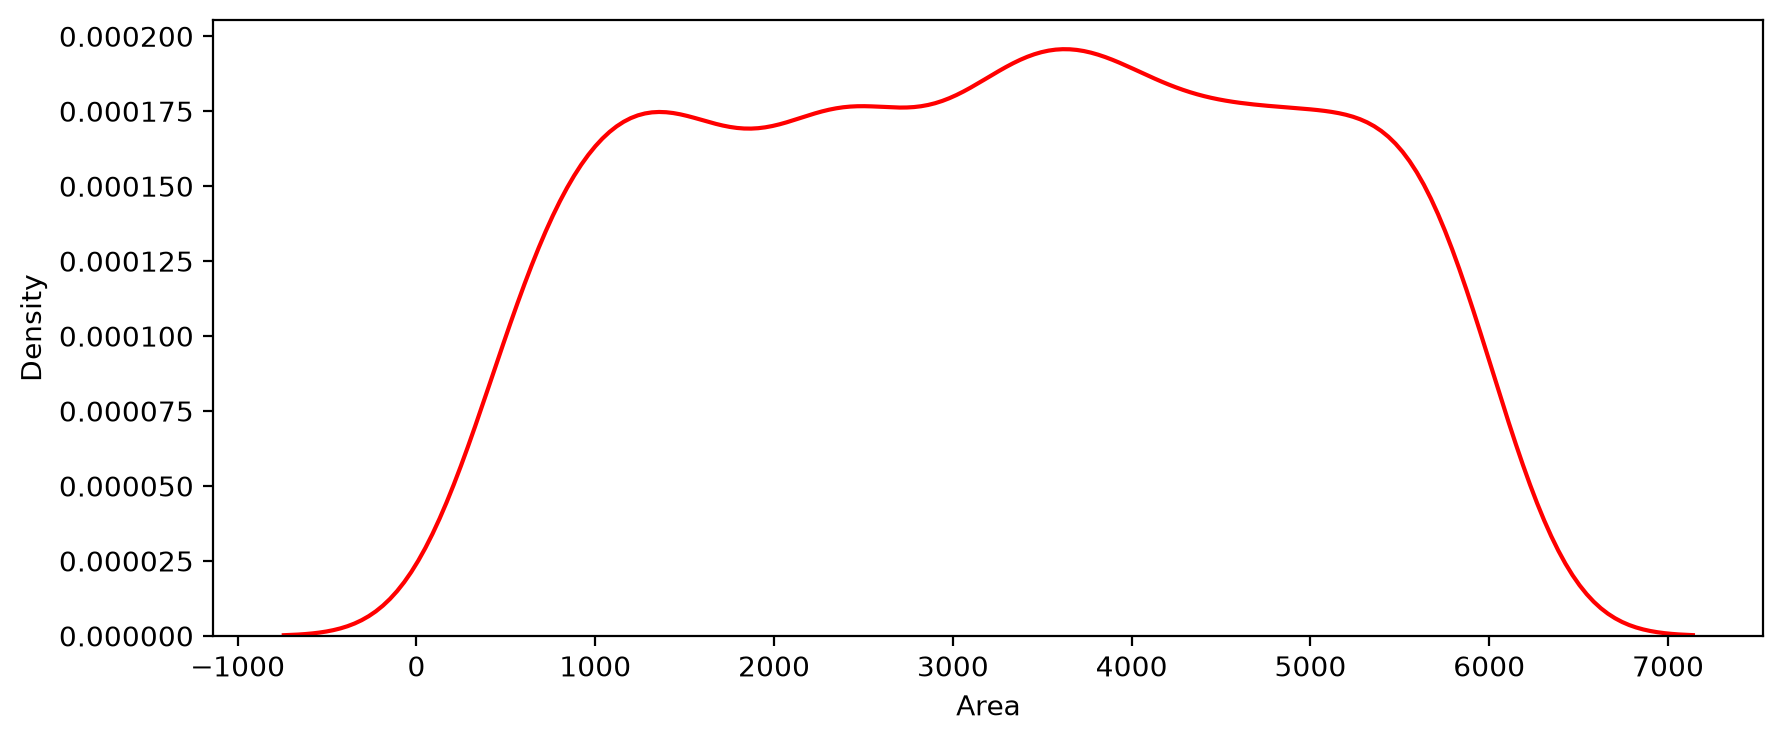

In [46]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Area,color='Red',hist = False)

<Axes: xlabel='Bedrooms', ylabel='Density'>

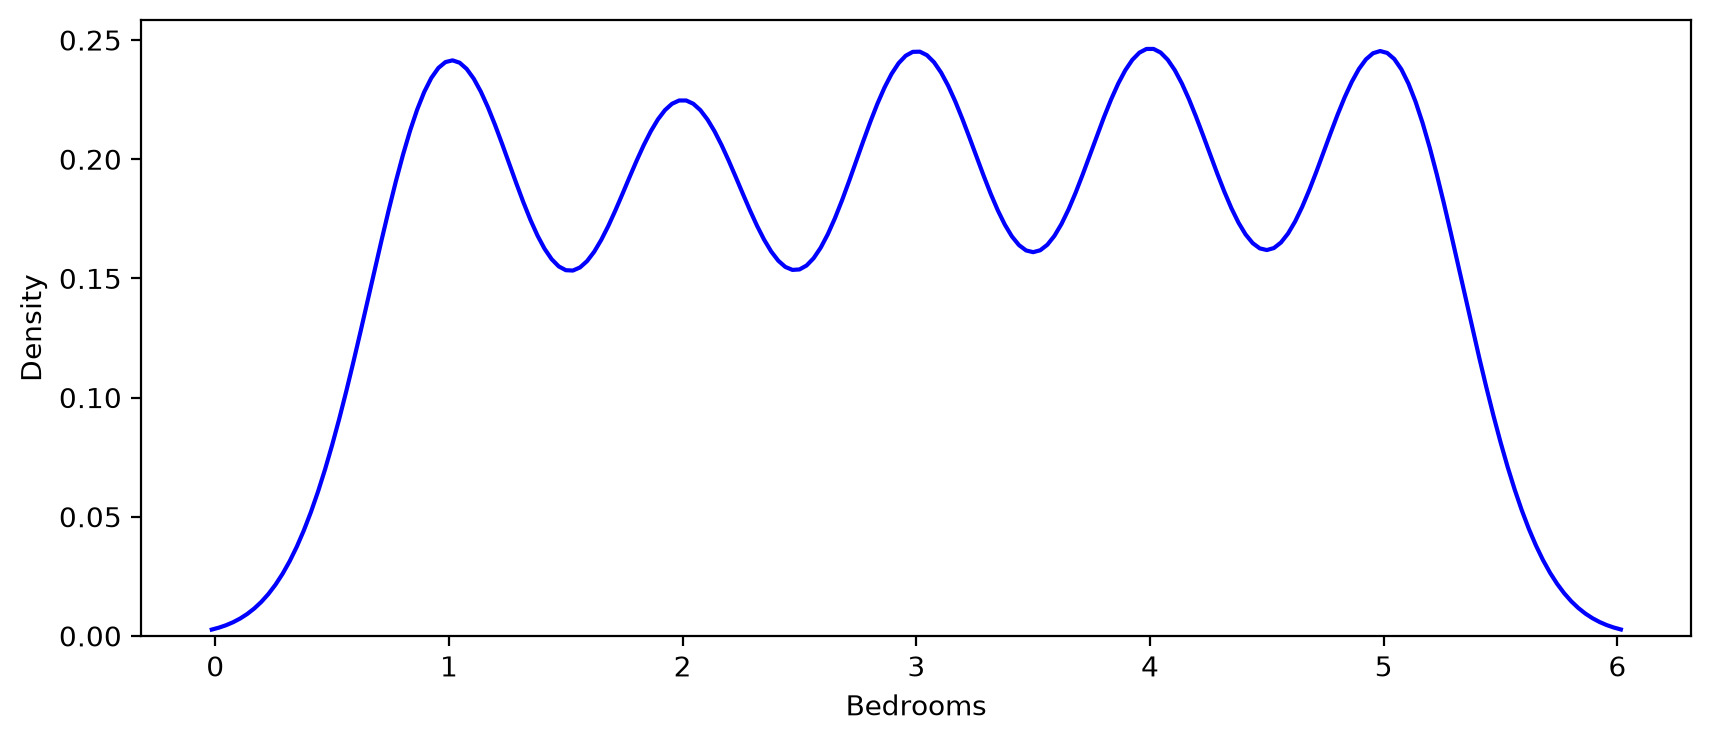

In [45]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Bedrooms,color='b',hist = False)

<Axes: xlabel='Bathrooms', ylabel='Density'>

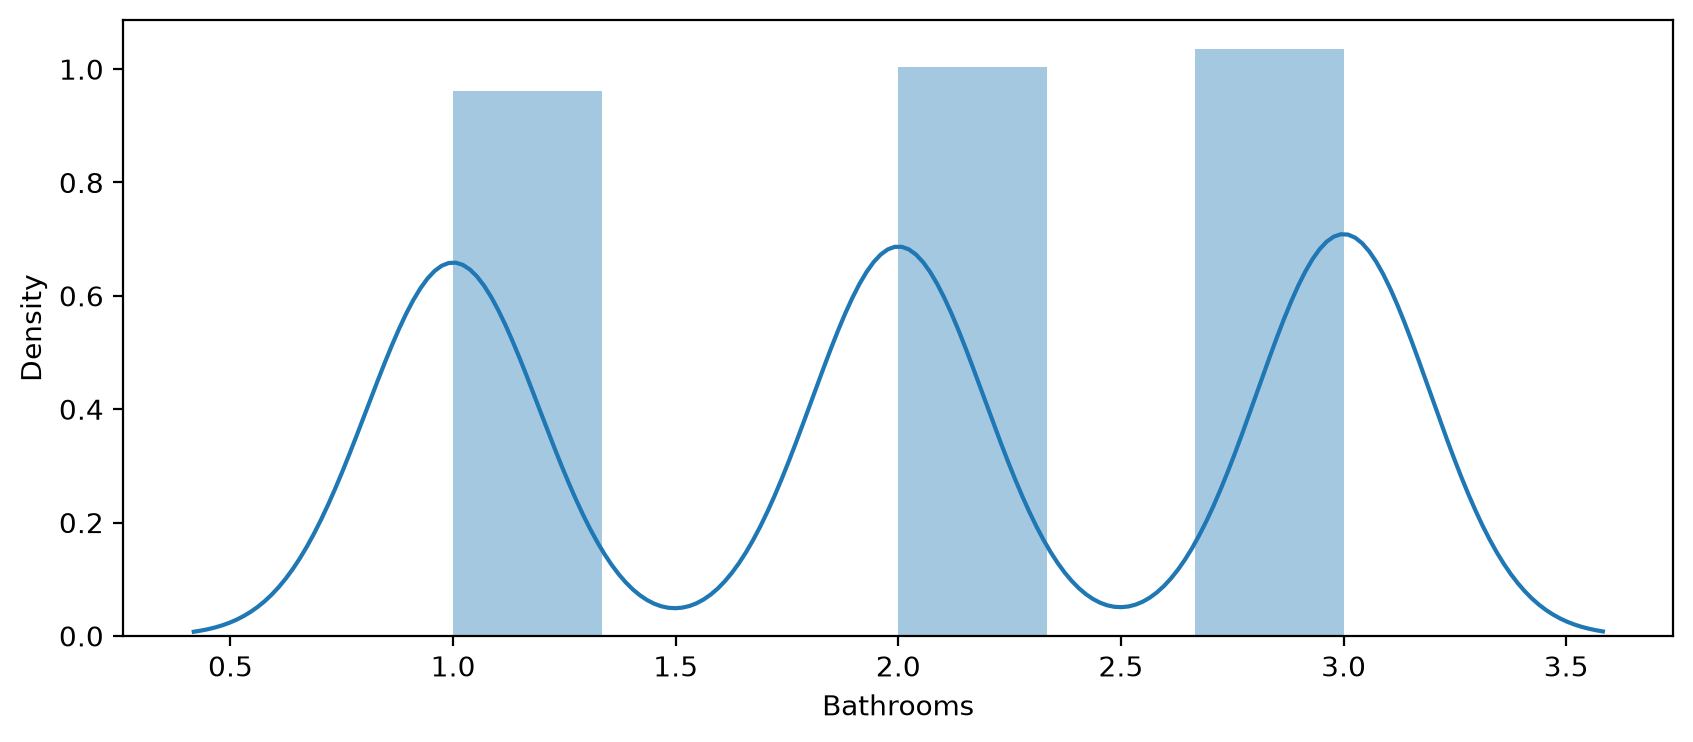

In [44]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Bathrooms)

<Axes: xlabel='Stories', ylabel='Density'>

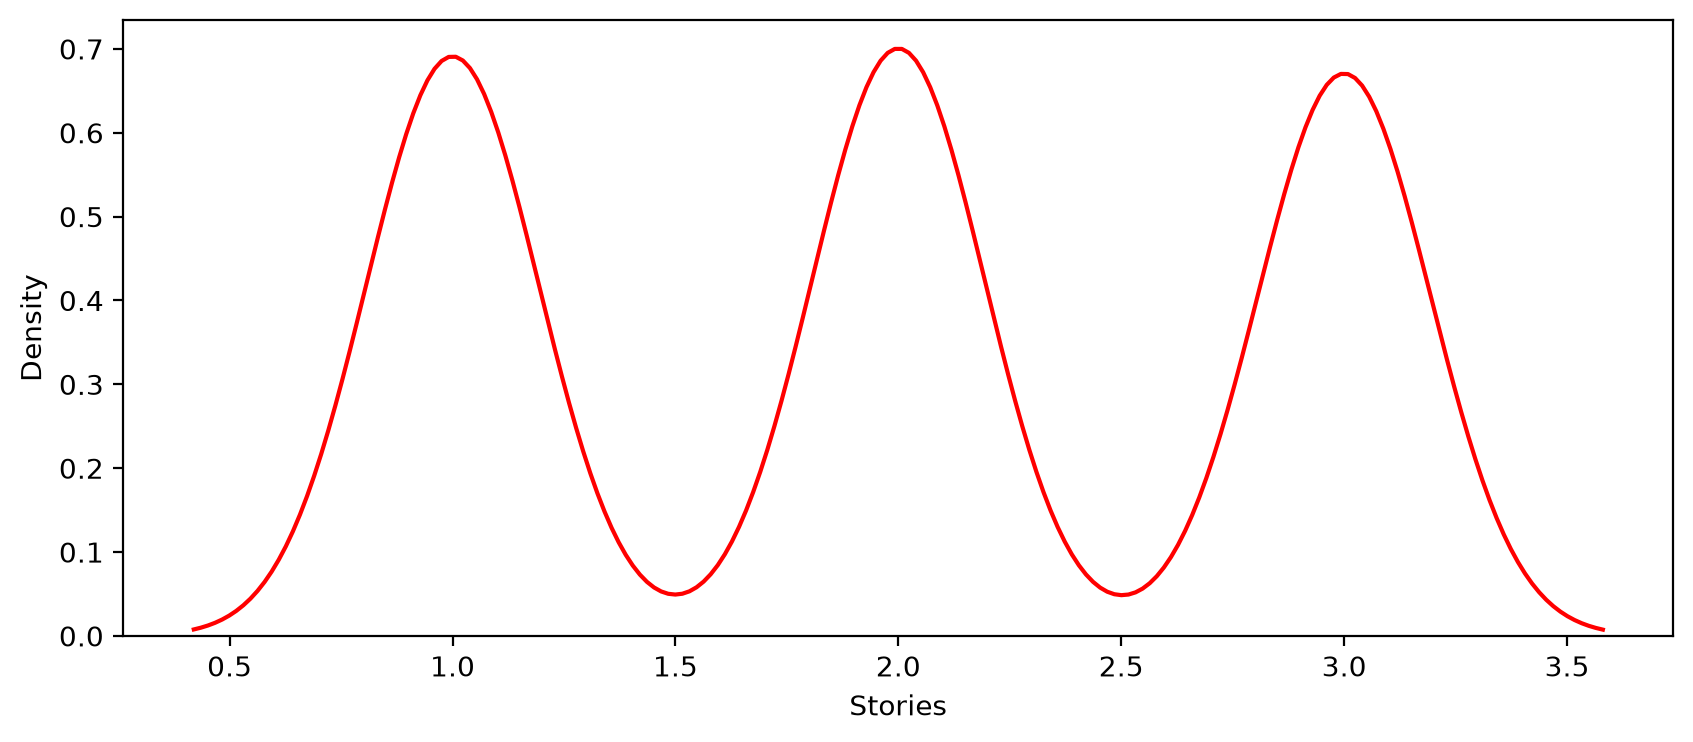

In [40]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Stories,color='Red',hist = False)

<Axes: xlabel='Parking', ylabel='Density'>

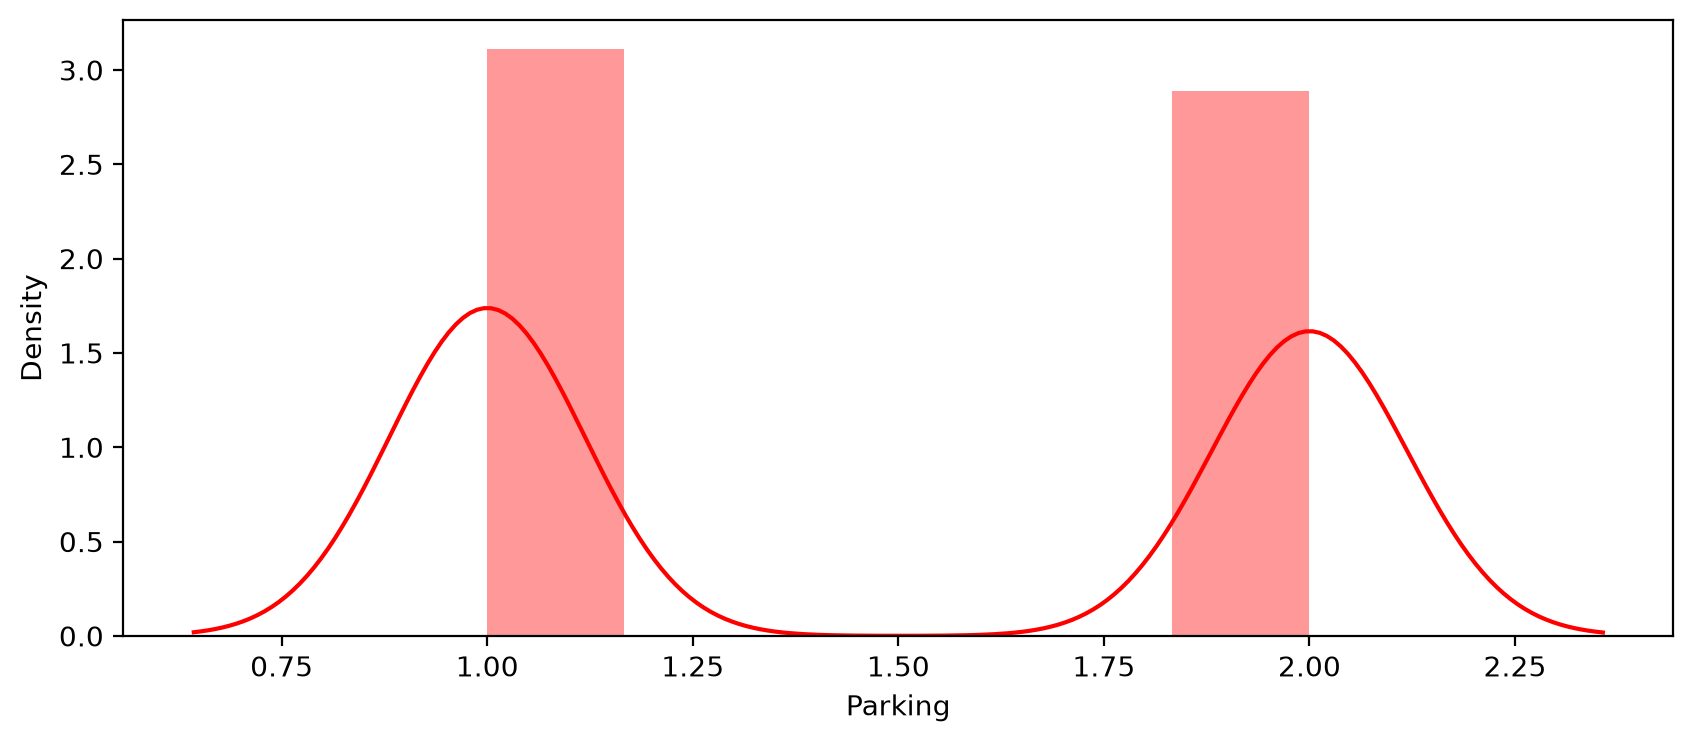

In [52]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Parking,color='Red')

<Axes: xlabel='Age', ylabel='Density'>

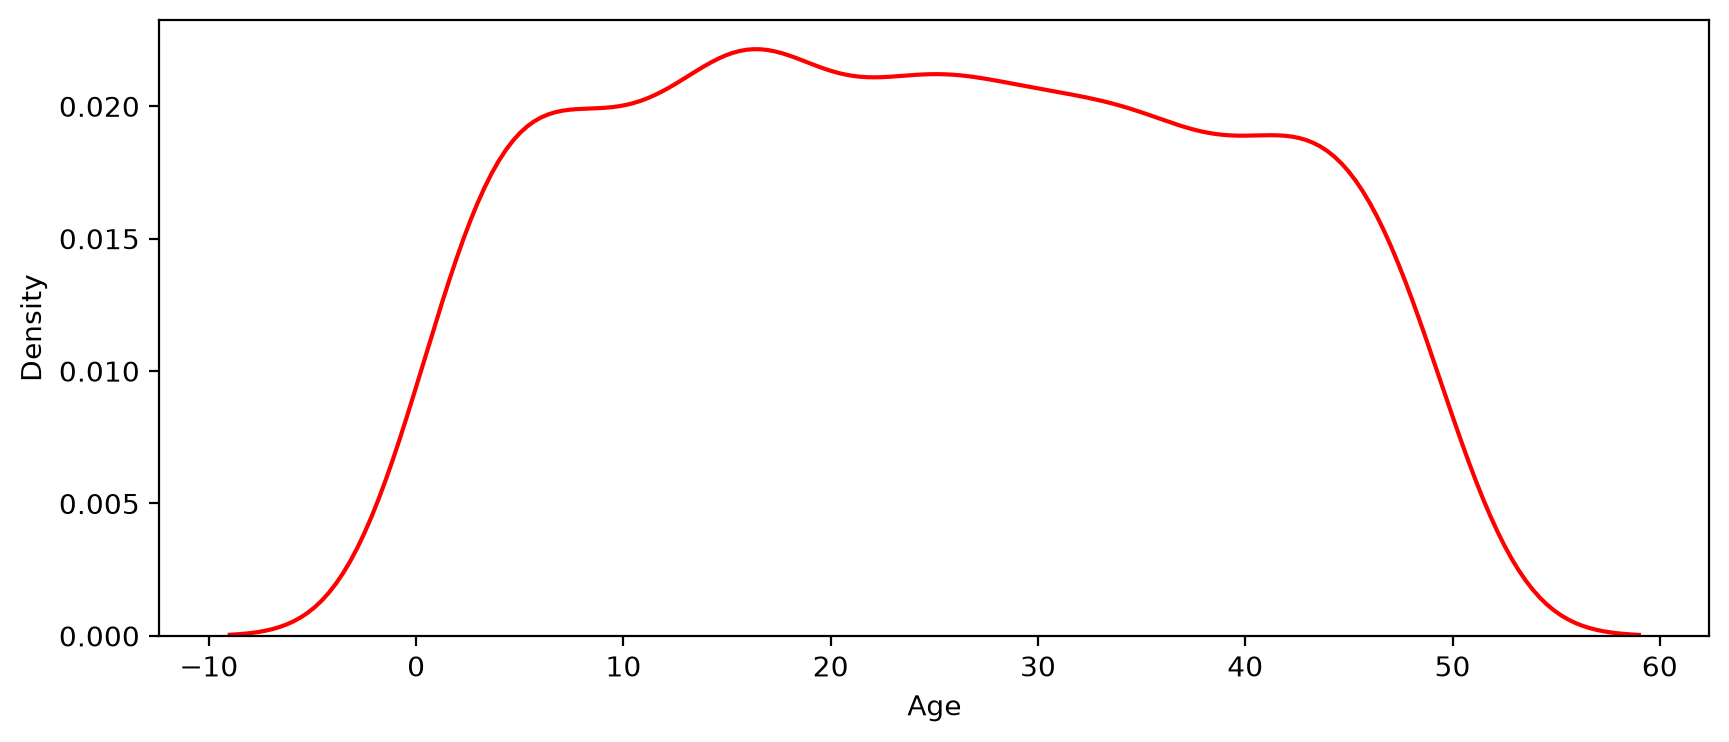

In [53]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Age,color='Red',hist = False)

<Axes: xlabel='Price', ylabel='Density'>

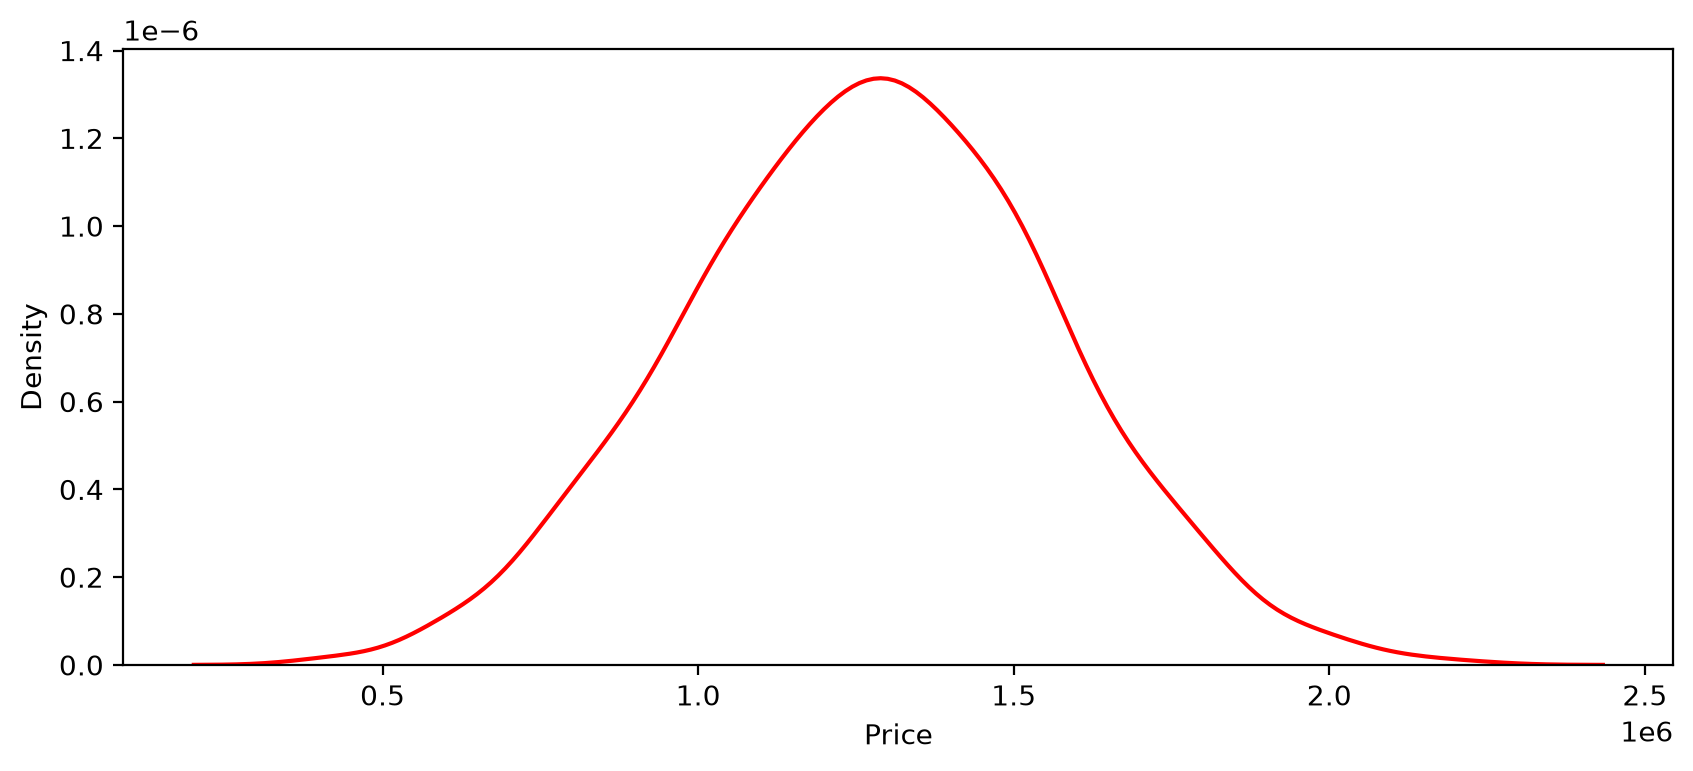

In [54]:
plt.figure(figsize = (10,4),dpi=200)
sns.distplot(df.Price,color='Red',hist = False)

LINE PLOT

1 - NUMERICAL 2 - NUMERICAL

<Axes: xlabel='Area', ylabel='Price'>

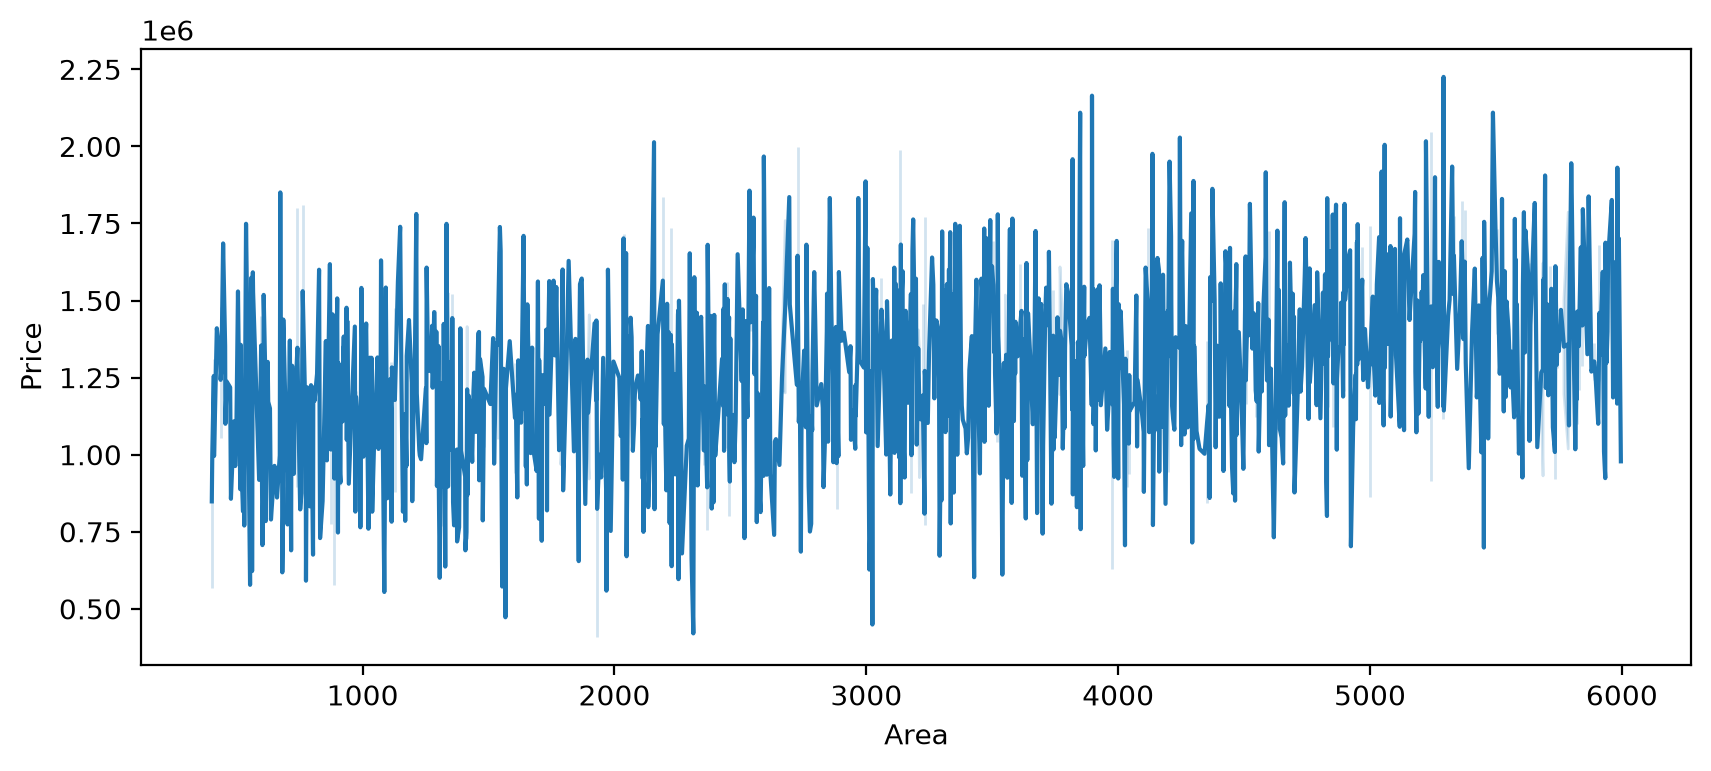

In [57]:
plt.figure(figsize = (10,4),dpi=200)
sns.lineplot(x='Area',y='Price',data=df)

<Axes: xlabel='City', ylabel='Price'>

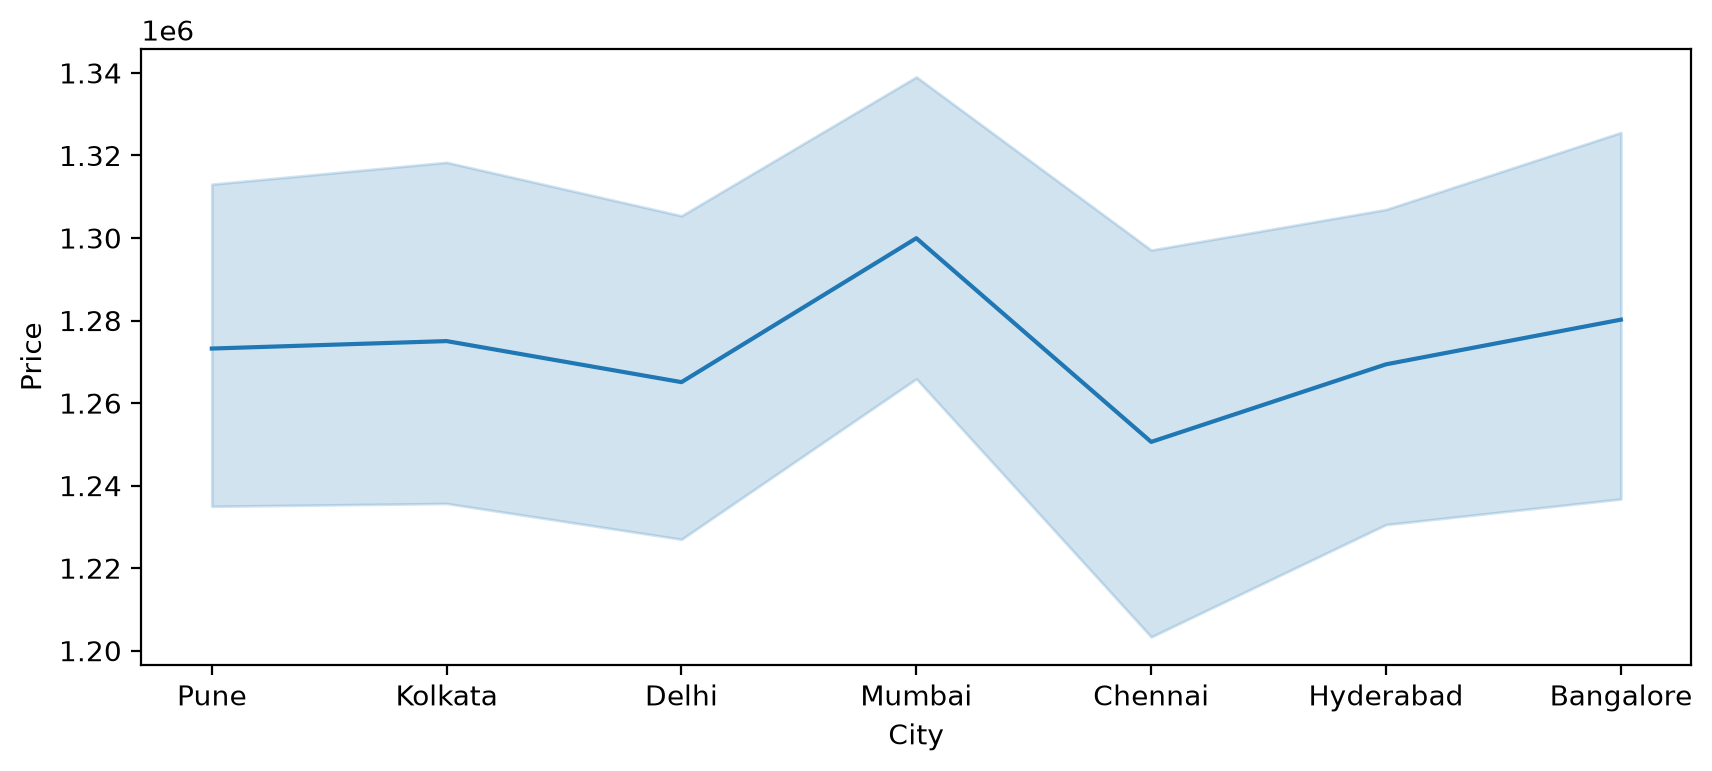

In [61]:
plt.figure(figsize = (10,4),dpi=200)
sns.lineplot(x='City',y='Price',data=df,markers=True)

<Axes: xlabel='Area', ylabel='Parking'>

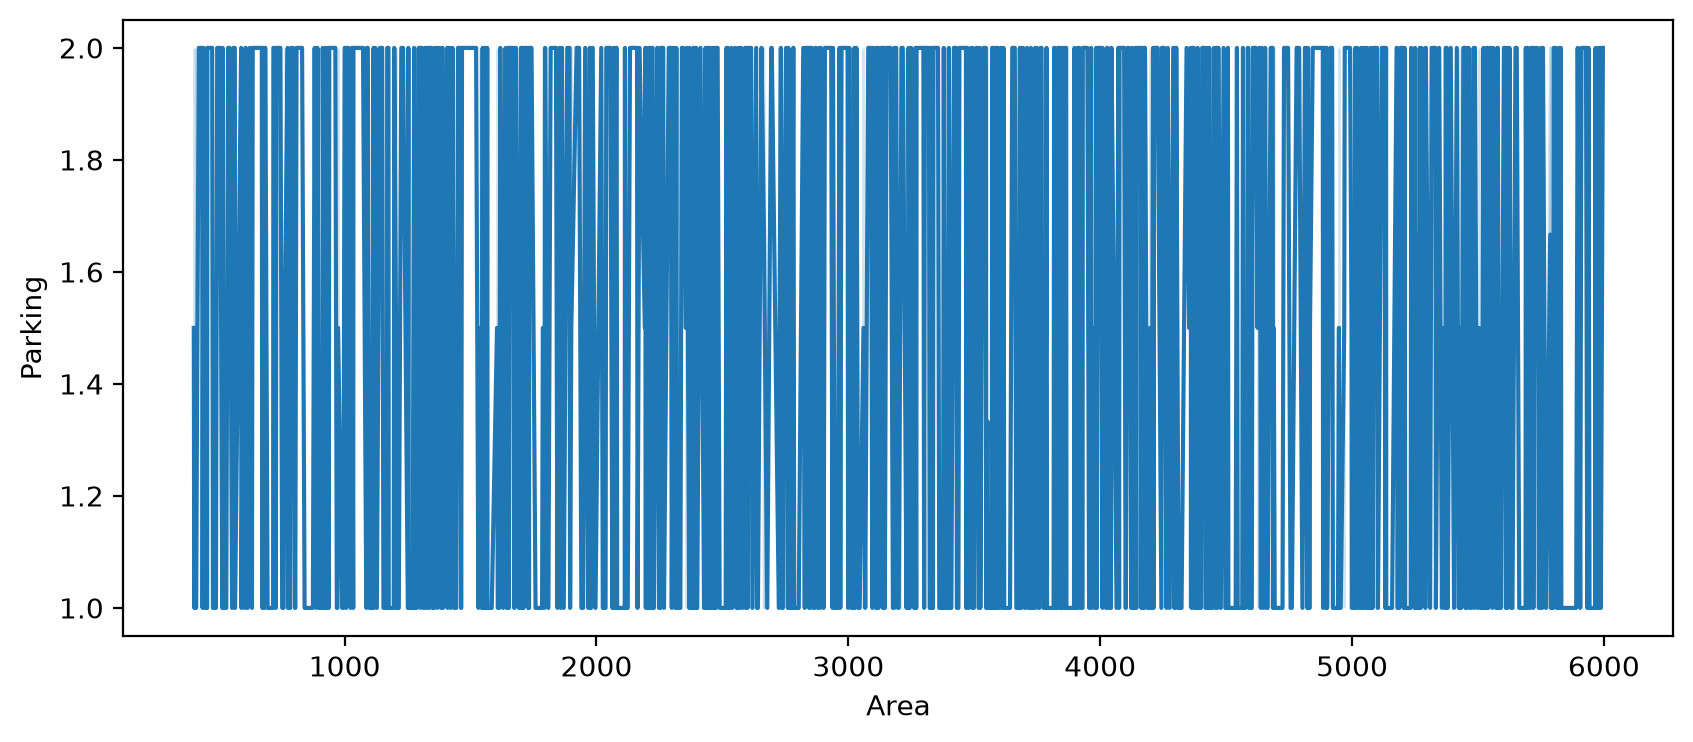

In [62]:
plt.figure(figsize = (10,4),dpi=200)
sns.lineplot(x='Area',y='Parking',data=df,markers=True)

<Axes: xlabel='Area', ylabel='Locality Rating'>

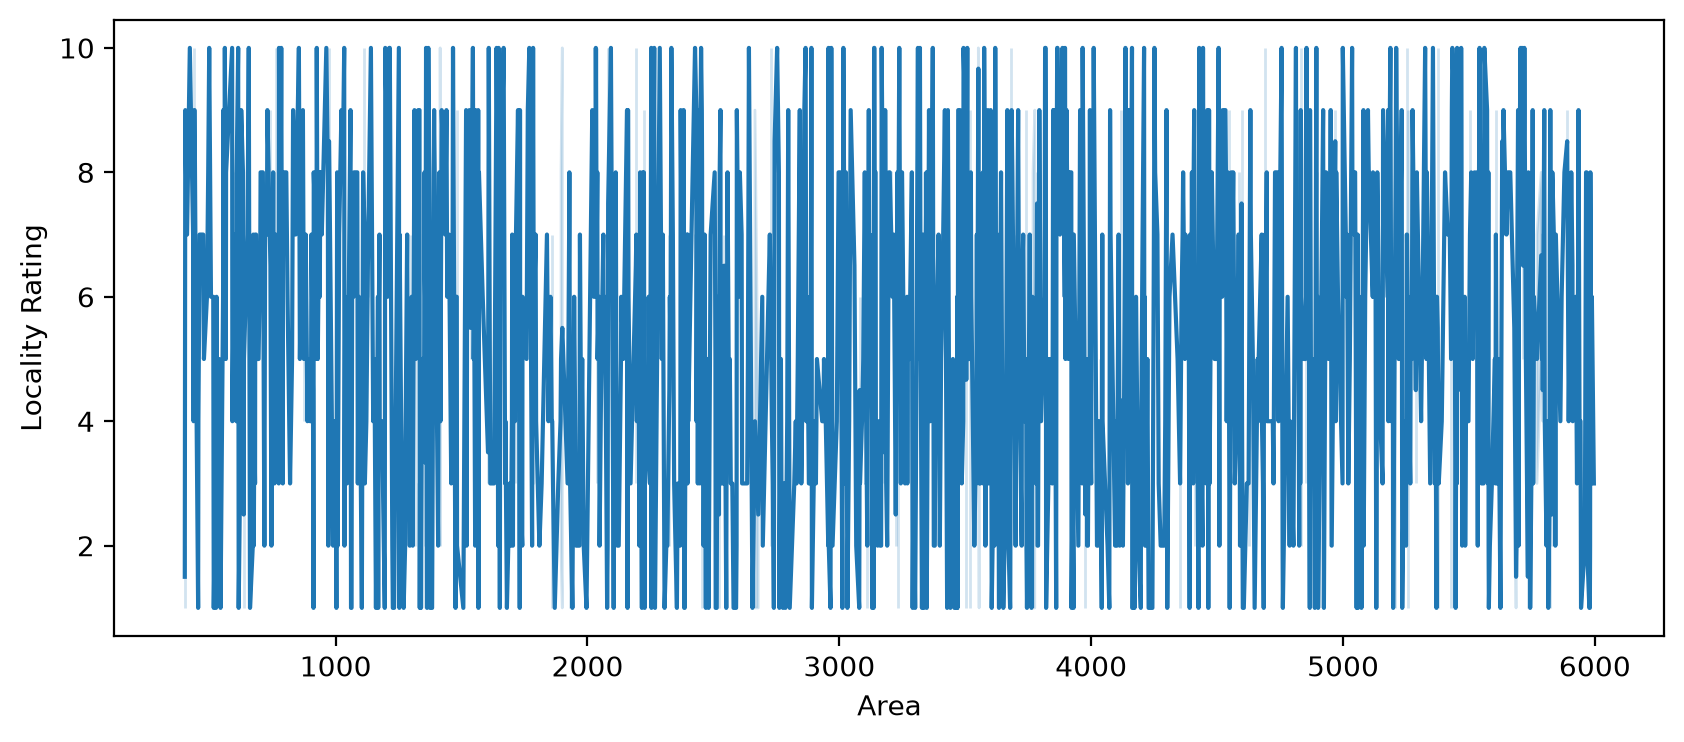

In [63]:
plt.figure(figsize = (10,4),dpi=200)
sns.lineplot(x='Area',y='Locality Rating',data=df,markers=True)

SCATTER PLOT¶

<Axes: xlabel='Locality Rating', ylabel='Price'>

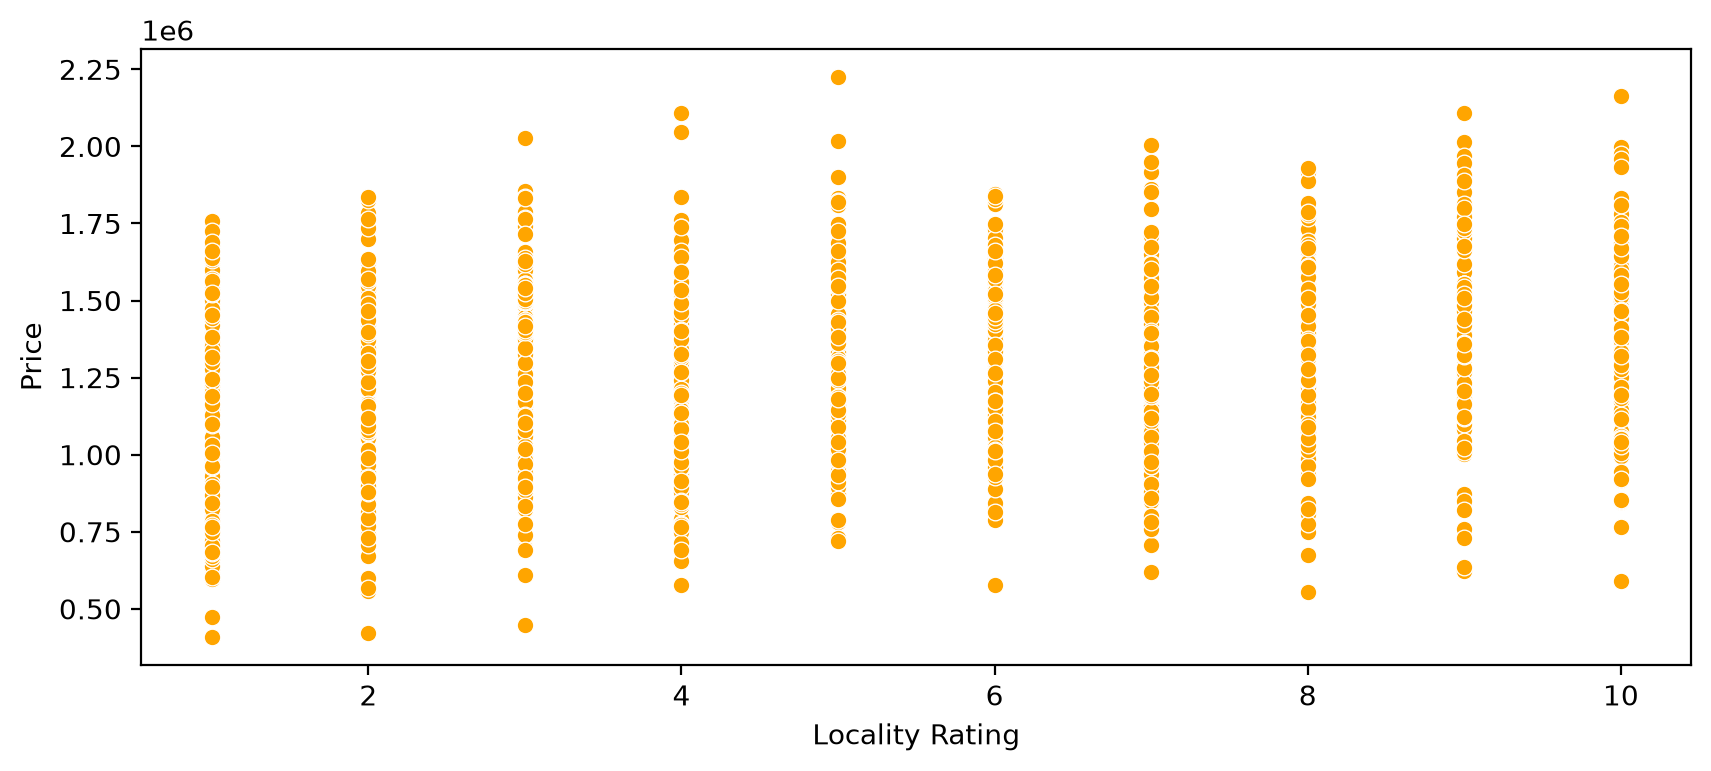

In [65]:
plt.figure(figsize = (10,4),dpi=200)
sns.scatterplot(x='Locality Rating',y='Price', data = df,color = 'orange')

<Axes: xlabel='Locality Rating', ylabel='Area'>

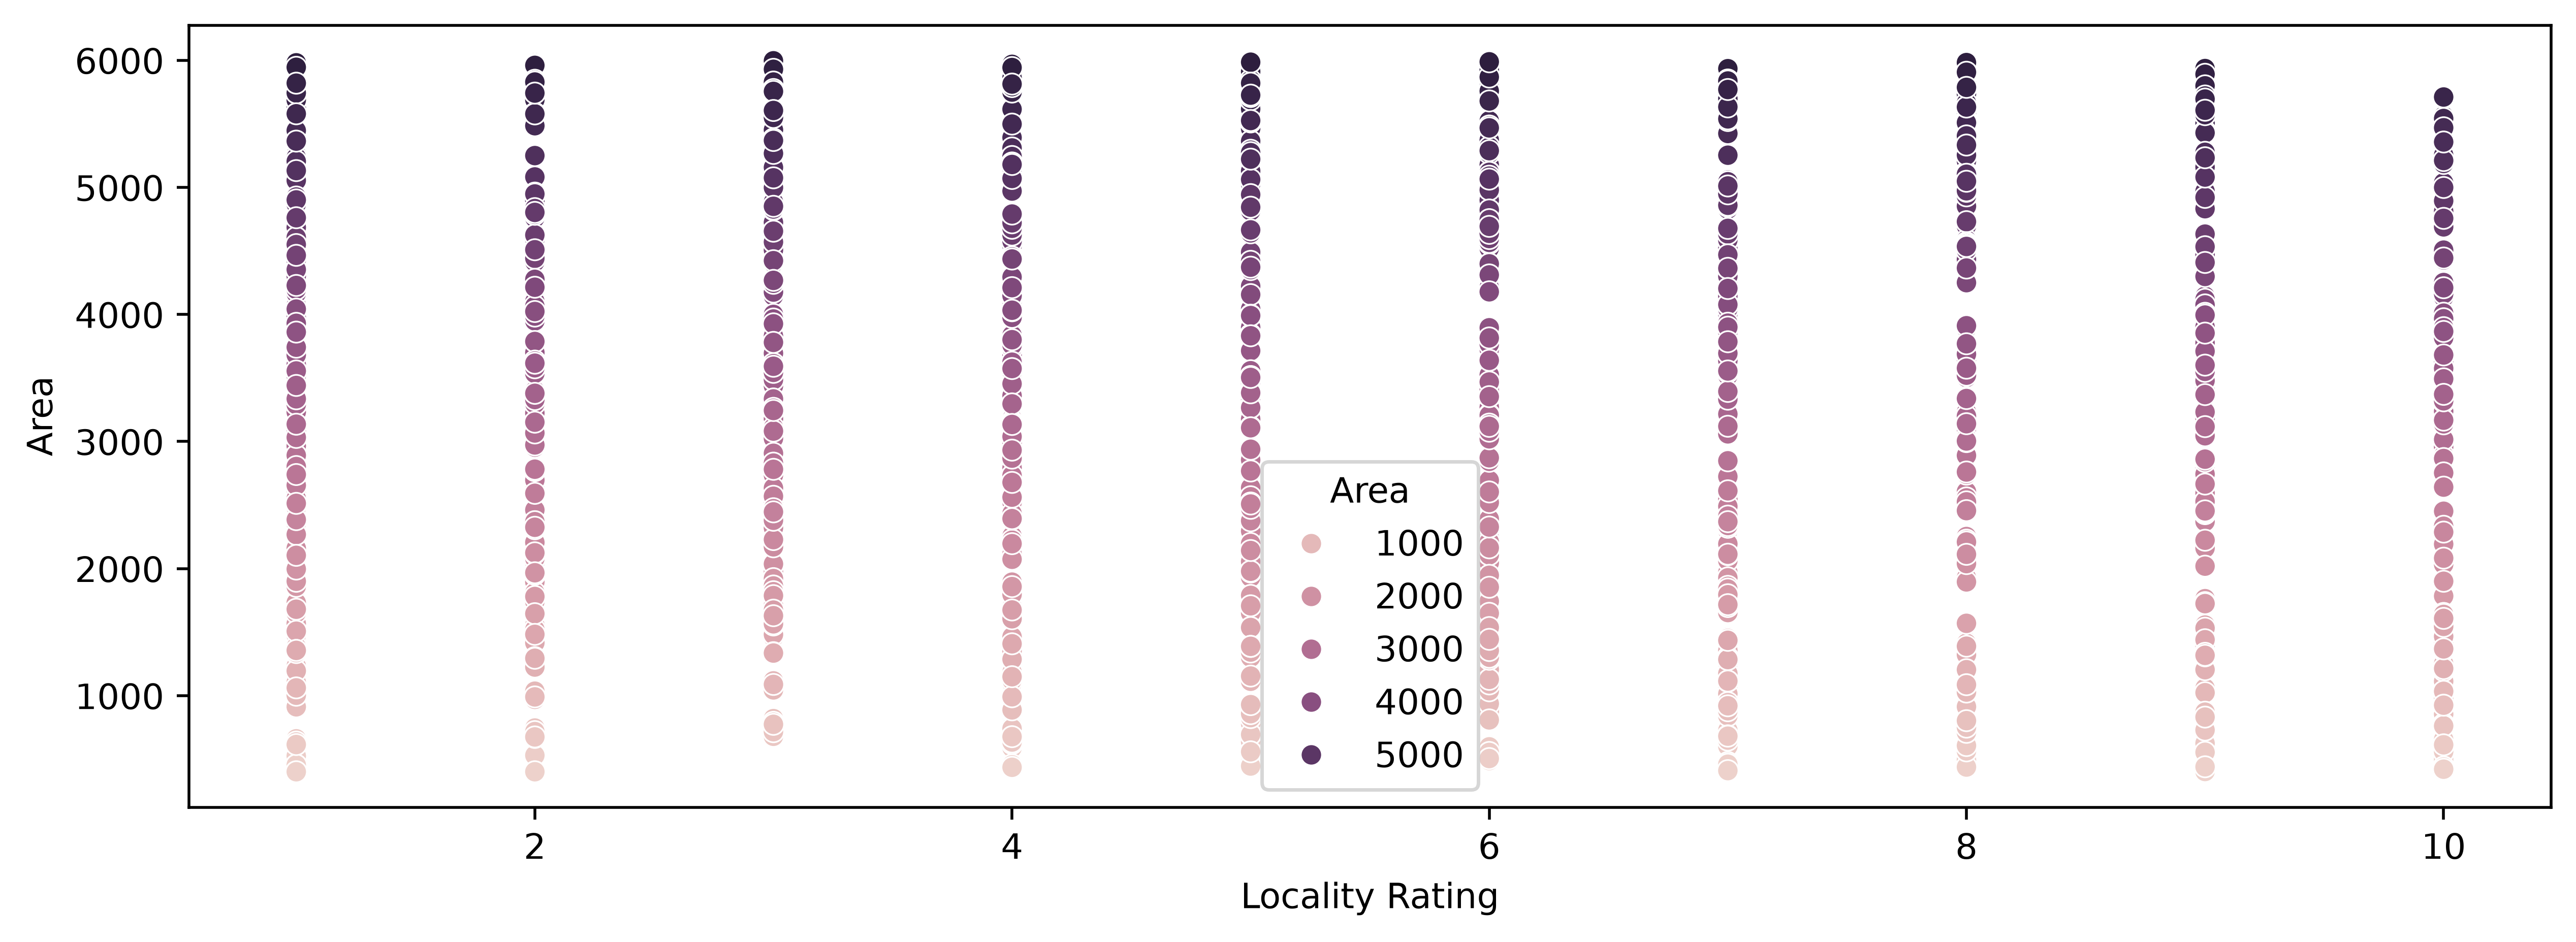

In [70]:
plt.figure(figsize = (12,4),dpi=500)
sns.scatterplot(x='Locality Rating',y='Area', data = df,color = 'red',hue = 'Area')

<Axes: xlabel='City', ylabel='Price'>

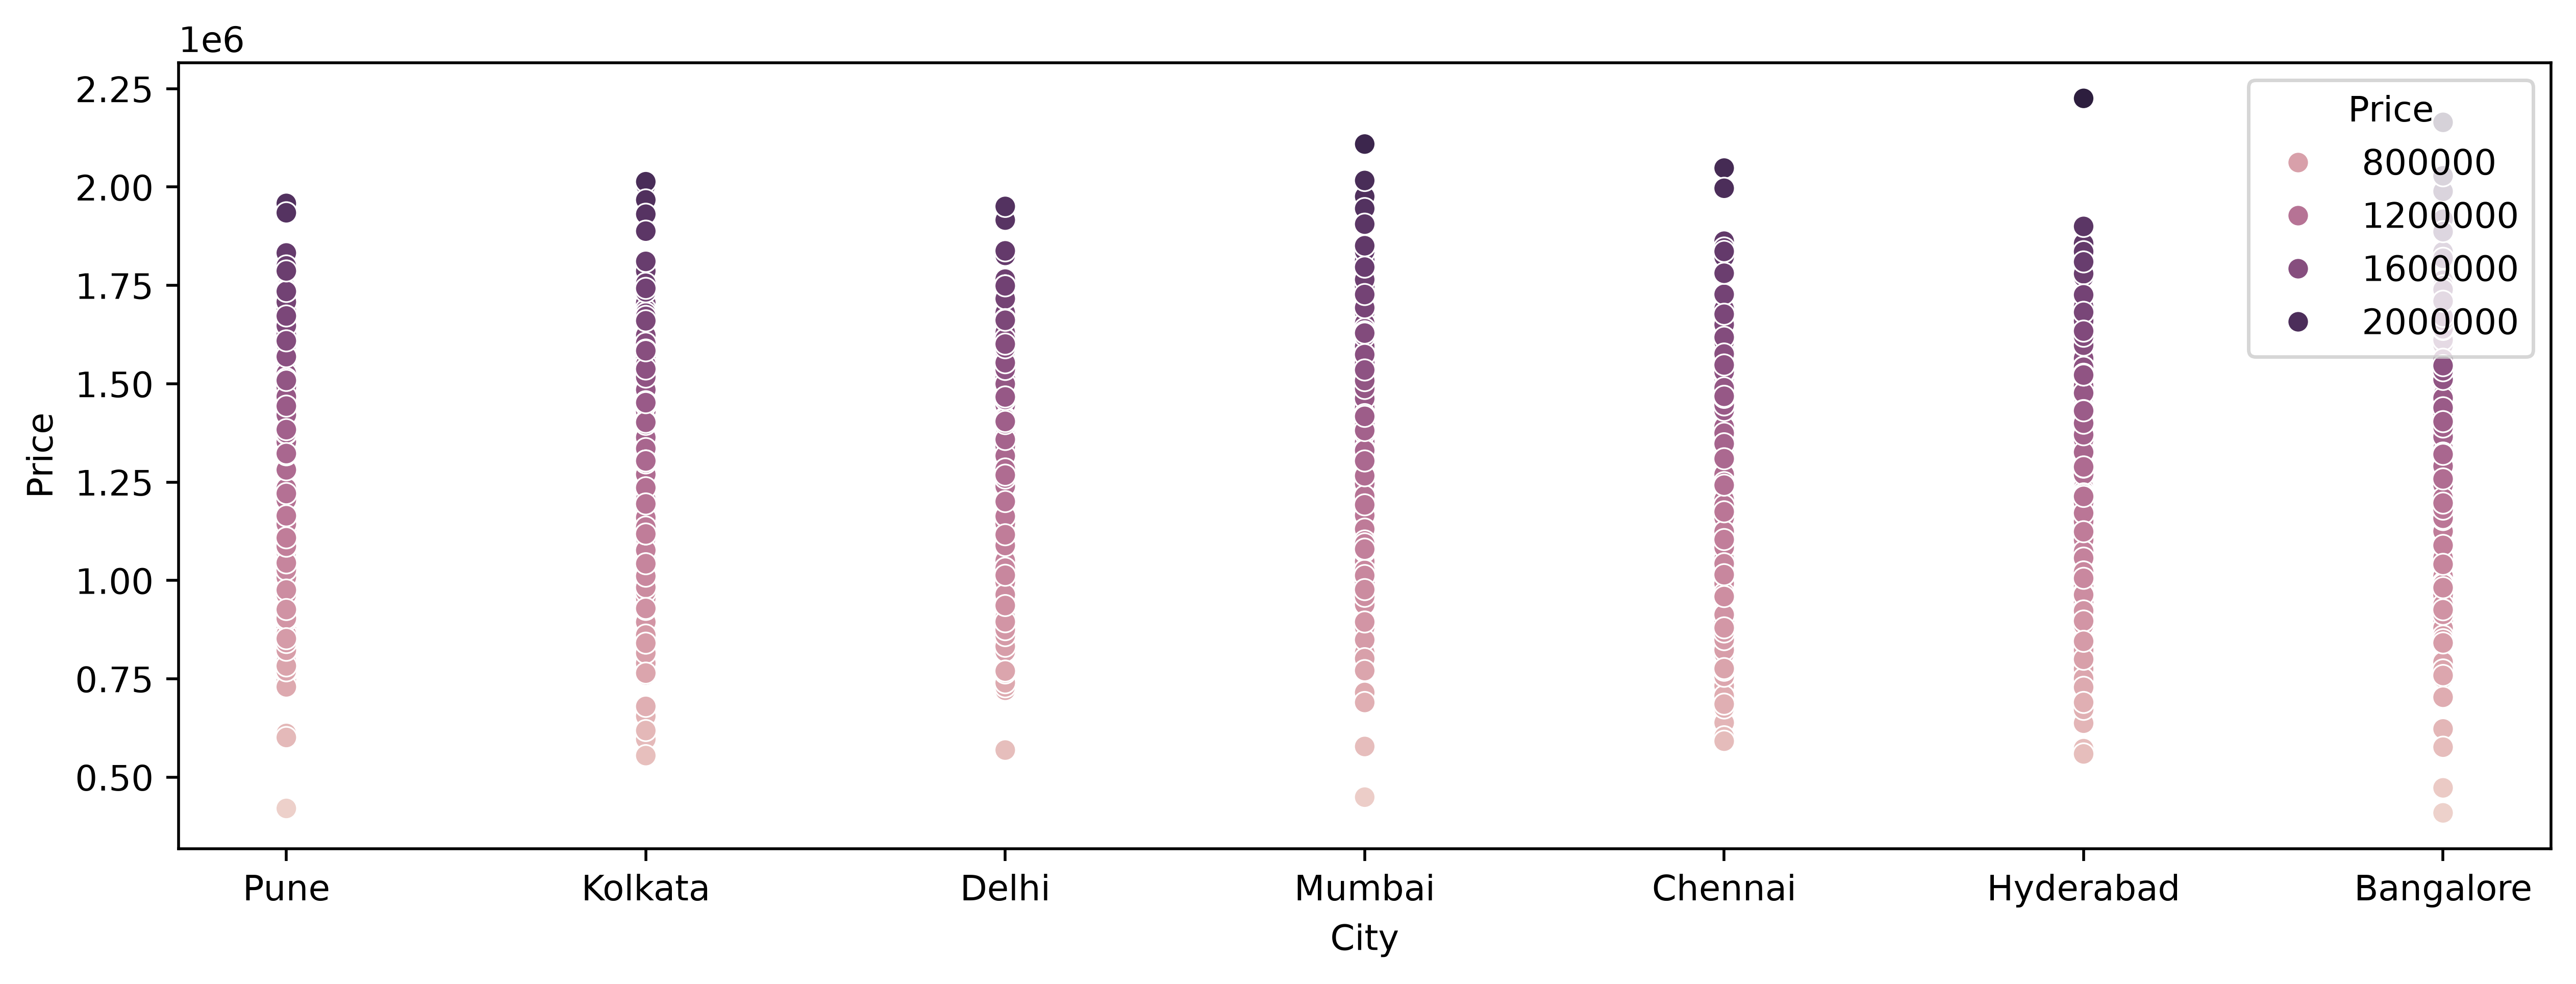

In [71]:
plt.figure(figsize = (12,4),dpi=500)
sns.scatterplot(x='City',y='Price', data = df,color = 'red',hue = 'Price')

<Axes: xlabel='City', ylabel='Price'>

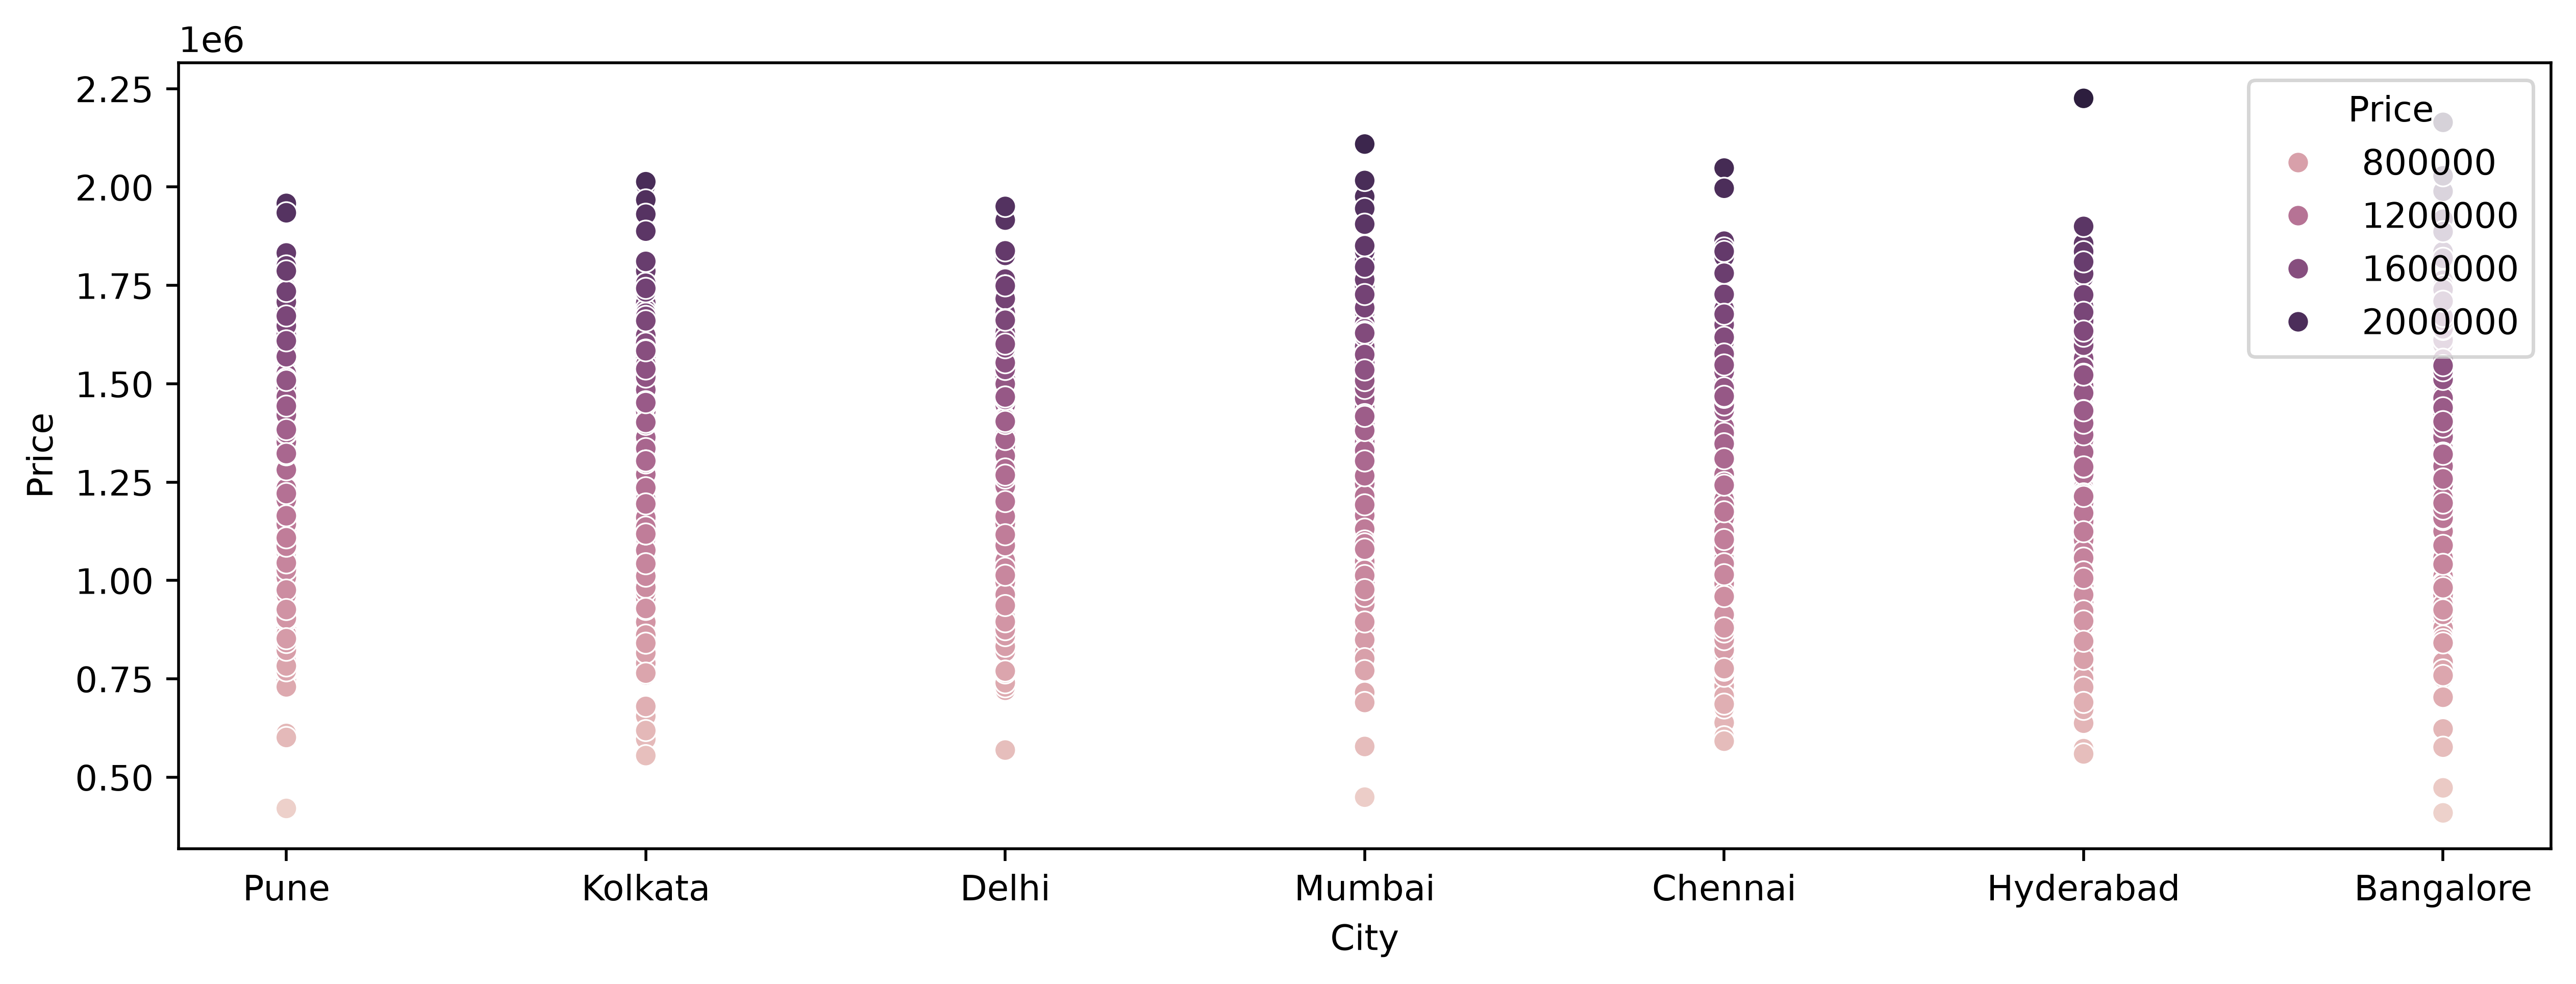

In [72]:
plt.figure(figsize = (12,4),dpi=500)
sns.scatterplot(x='City',y='Price', data = df,color = 'red',hue = 'Price',markers=True)

BAR PLOT

<Axes: xlabel='Bedrooms', ylabel='Bathrooms'>

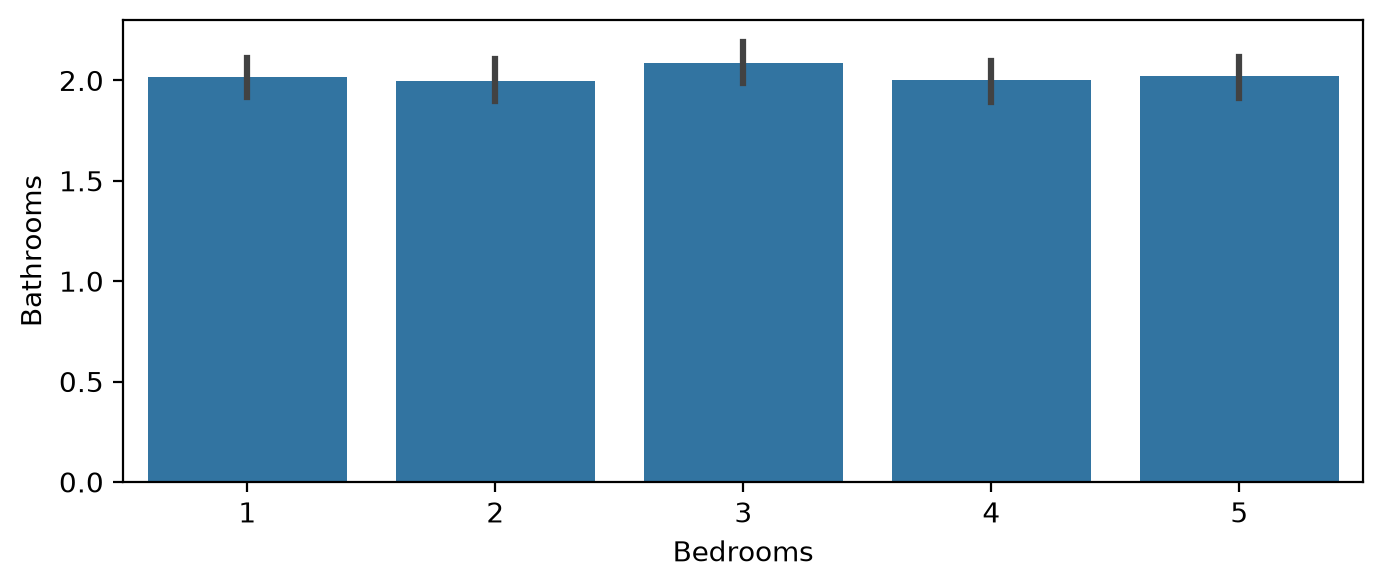

In [75]:
plt.figure(figsize = (8,3),dpi=200)
sns.barplot(x='Bedrooms',y='Bathrooms',data=df)

<Axes: xlabel='Age', ylabel='Area'>

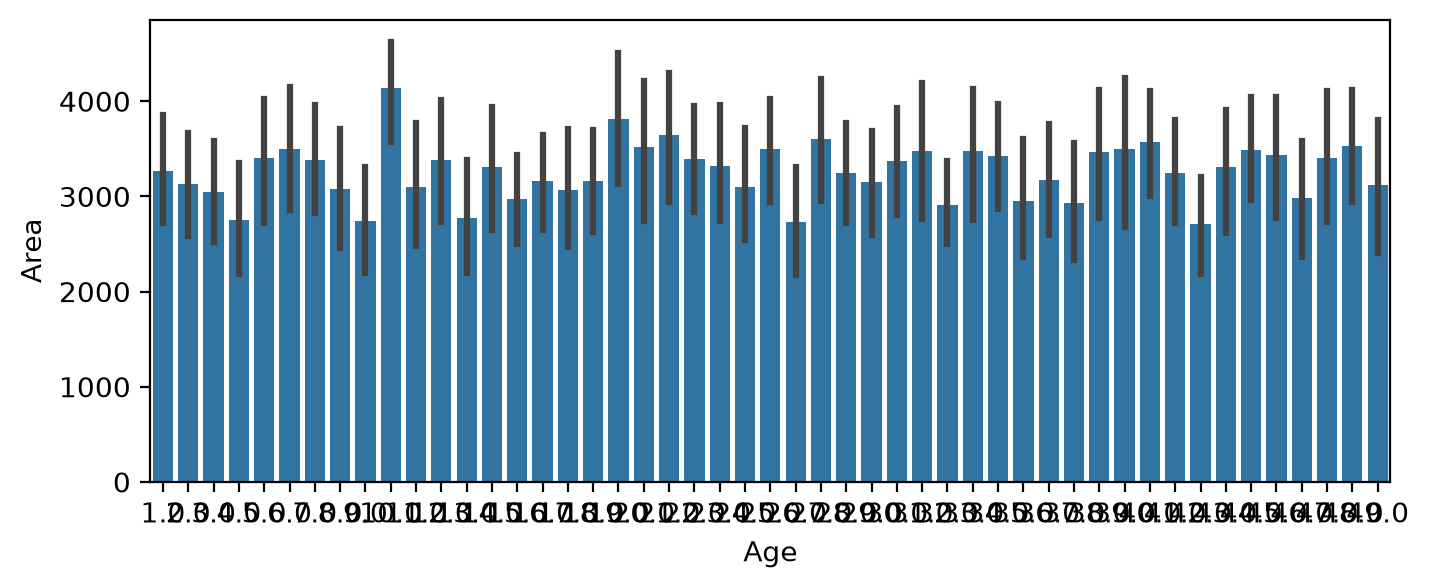

In [76]:
plt.figure(figsize = (8,3),dpi=200)
sns.barplot(x='Age',y='Area',data=df)

In [77]:
df.groupby(by='Bathrooms')['Bedrooms'].mean()

Bathrooms
1    2.990476
2    3.079909
3    3.002212
Name: Bedrooms, dtype: float64

<Axes: xlabel='Price', ylabel='Bedrooms'>

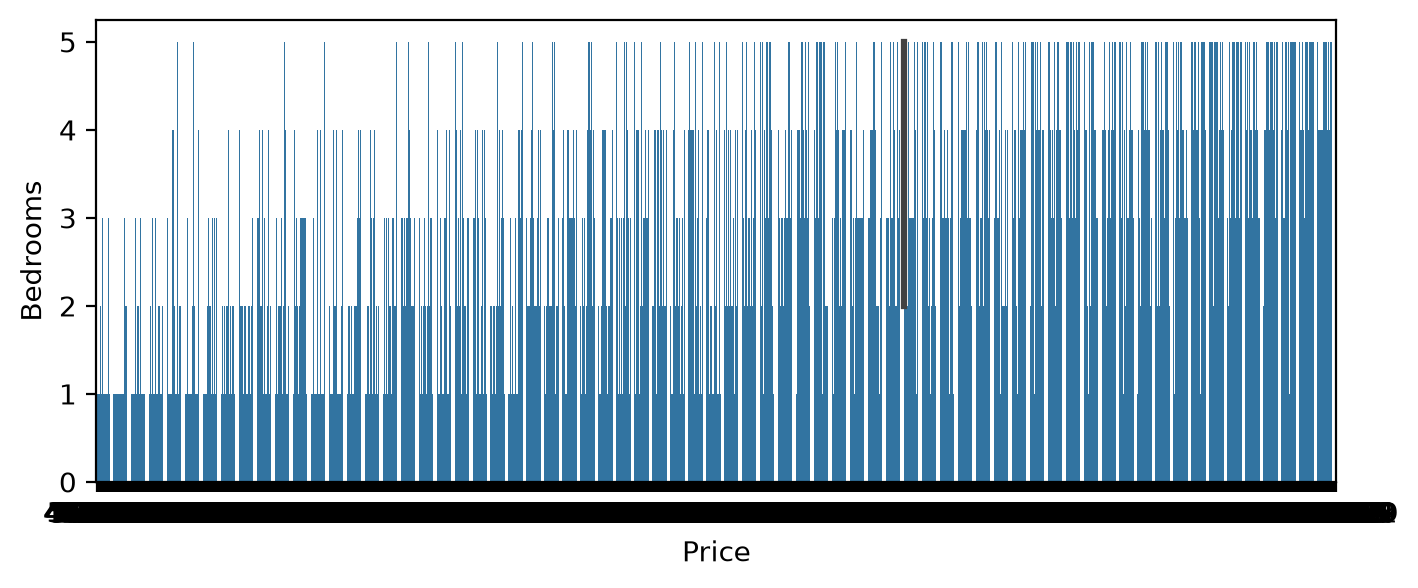

In [78]:
plt.figure(figsize = (8,3),dpi=200)
sns.barplot(x='Price',y='Bedrooms',data=df)

In [82]:
order = df.groupby(by = 'Bedrooms')['Price'].mean().sort_values().index
order

Index([1, 2, 3, 4, 5], dtype='int64', name='Bedrooms')

<Axes: xlabel='Bedrooms', ylabel='Price'>

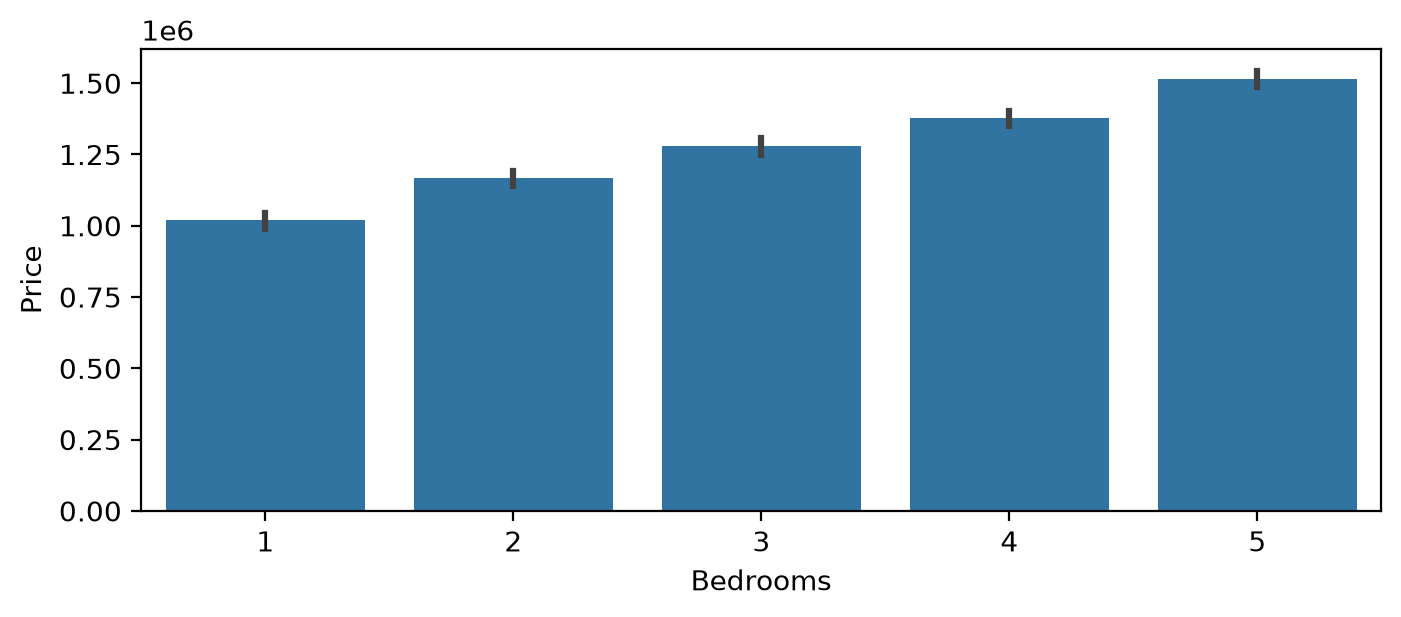

In [86]:
plt.figure(figsize = (8,3),dpi=200)
sns.barplot(x='Bedrooms',y='Price',data=df,order=order)

<Axes: xlabel='Bedrooms', ylabel='Price'>

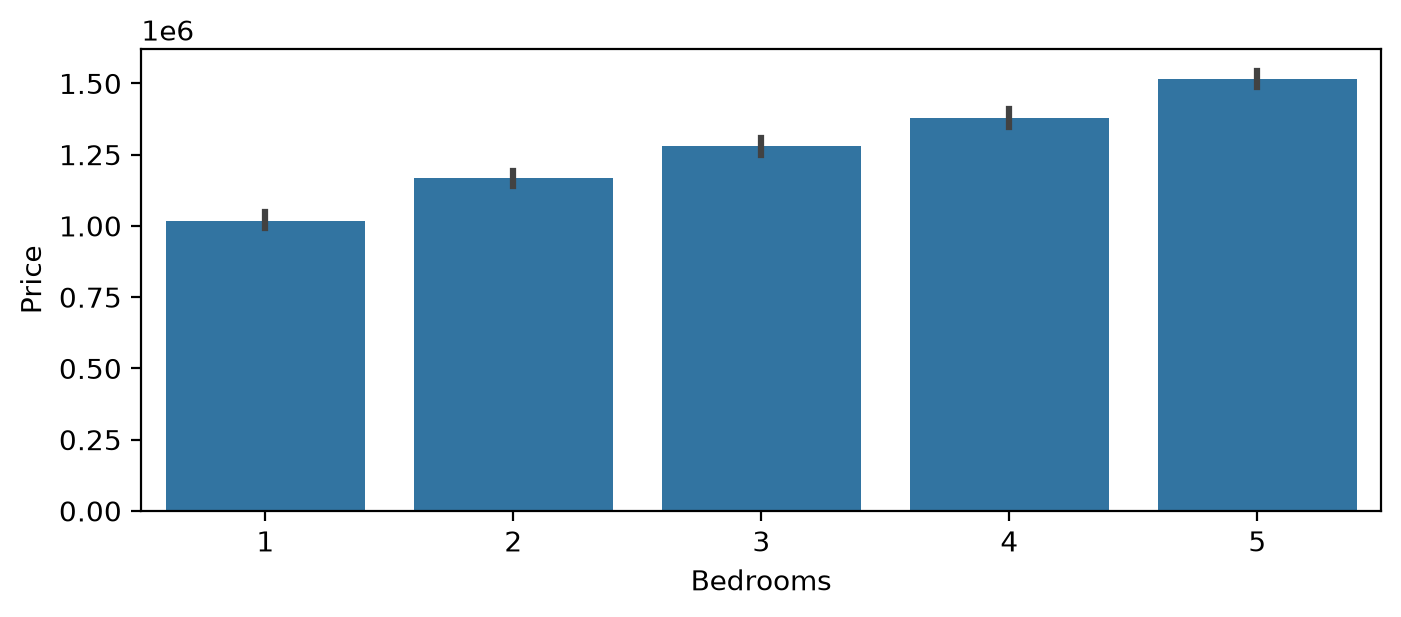

In [87]:
plt.figure(figsize = (8,3),dpi=200)
sns.barplot(x='Bedrooms',y='Price',data=df,order=order)

BOX PLOT

<Axes: xlabel='Price'>

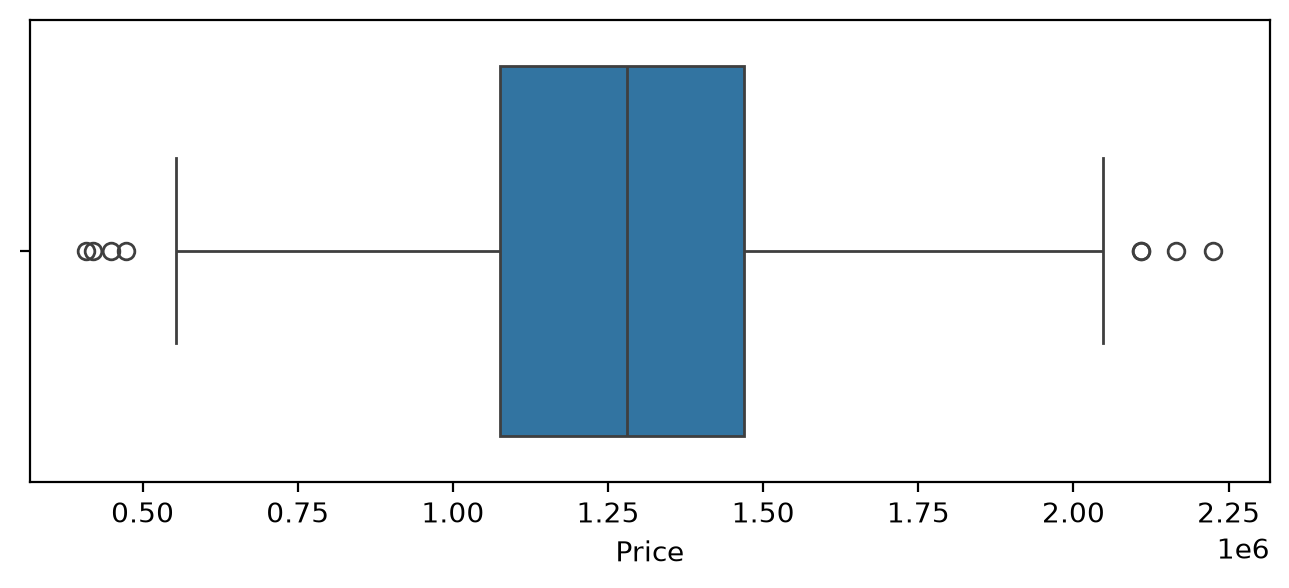

In [88]:
plt.figure(figsize = (8,3),dpi=200)
sns.boxplot(x='Price',data=df)

<Axes: ylabel='Price'>

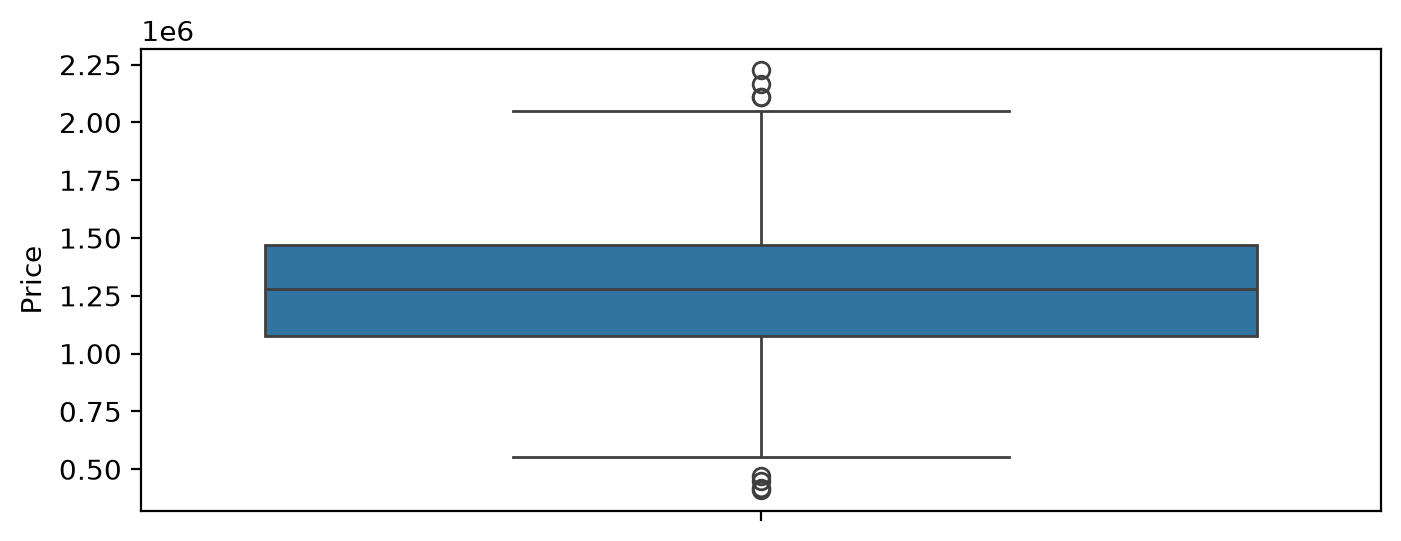

In [89]:
plt.figure(figsize = (8,3),dpi=200)
sns.boxplot(y='Price',data=df)

In [91]:
df.Price.quantile(.25)

np.float64(1076465.25)

In [93]:
df.Price.quantile(.5)

np.float64(1280228.5)

In [94]:
df.Price.quantile(.5)

np.float64(1280228.5)

In [95]:
df.Price.quantile(1)

np.float64(2225409.0)

<Axes: xlabel='Area', ylabel='City'>

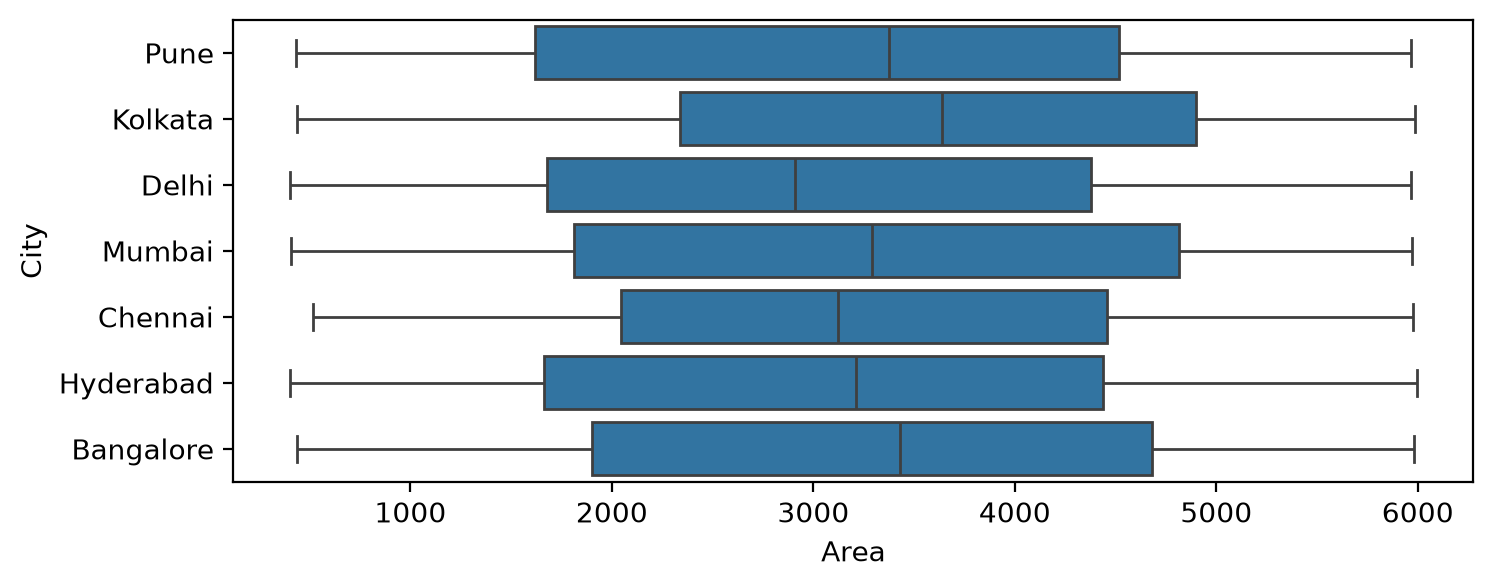

In [96]:
plt.figure(figsize = (8,3),dpi=200)
sns.boxplot(x='Area',y='City',data=df)


COUNT PLOT

<Axes: xlabel='Price', ylabel='count'>

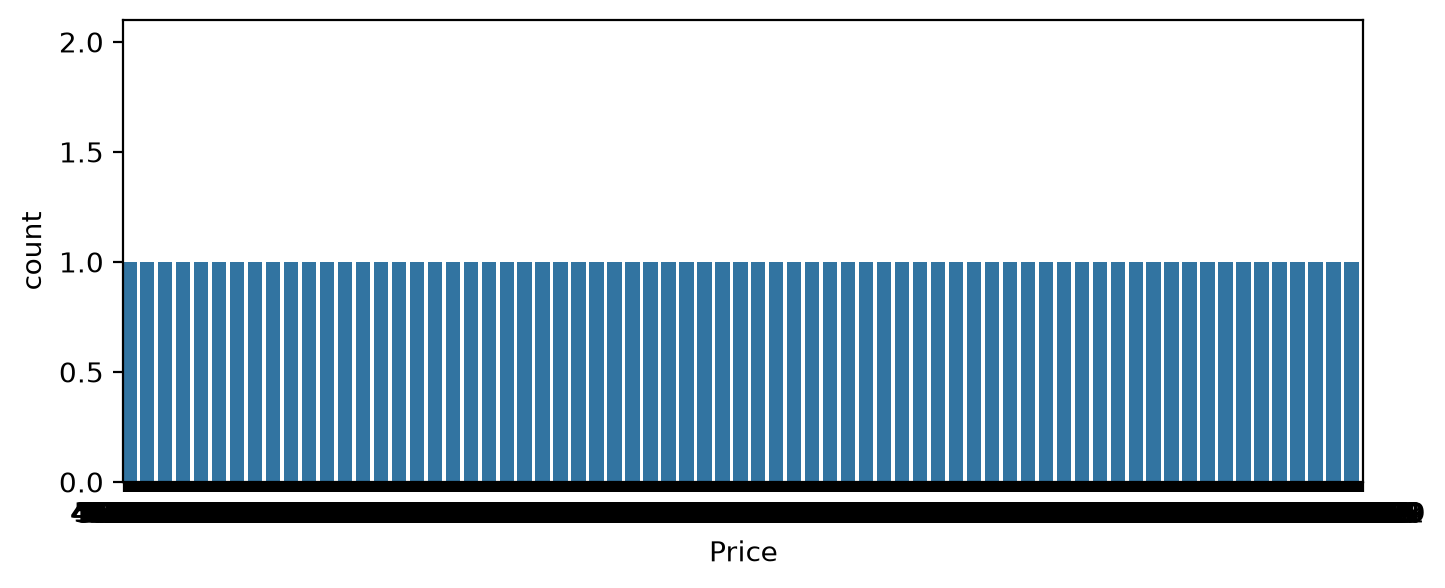

In [98]:
plt.figure(figsize = (8,3),dpi=200)

sns.countplot(x='Price',data=df)

In [99]:
df['Price'].value_counts()

Price
1389962    2
1274350    1
1094846    1
1003442    1
1306676    1
          ..
1194412    1
1303628    1
1135616    1
1117994    1
1547695    1
Name: count, Length: 1309, dtype: int64

<Axes: xlabel='Bedrooms', ylabel='count'>

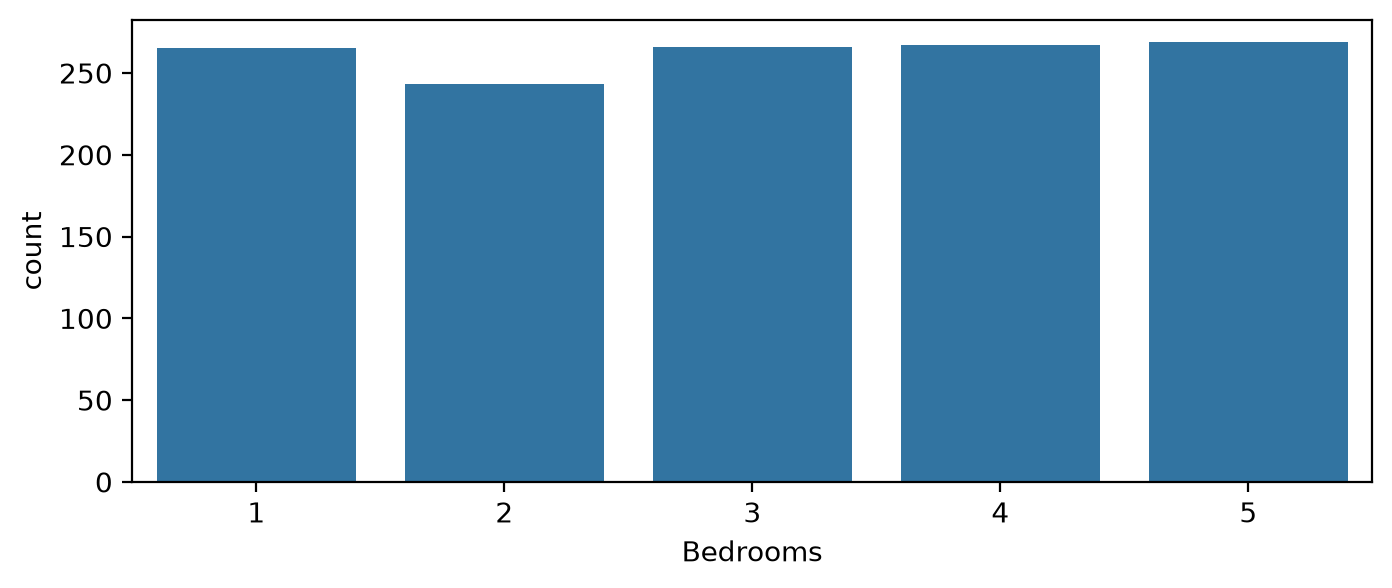

In [100]:
plt.figure(figsize = (8,3),dpi=200)
sns.countplot(x='Bedrooms',data=df)

<Figure size 3200x2400 with 0 Axes>

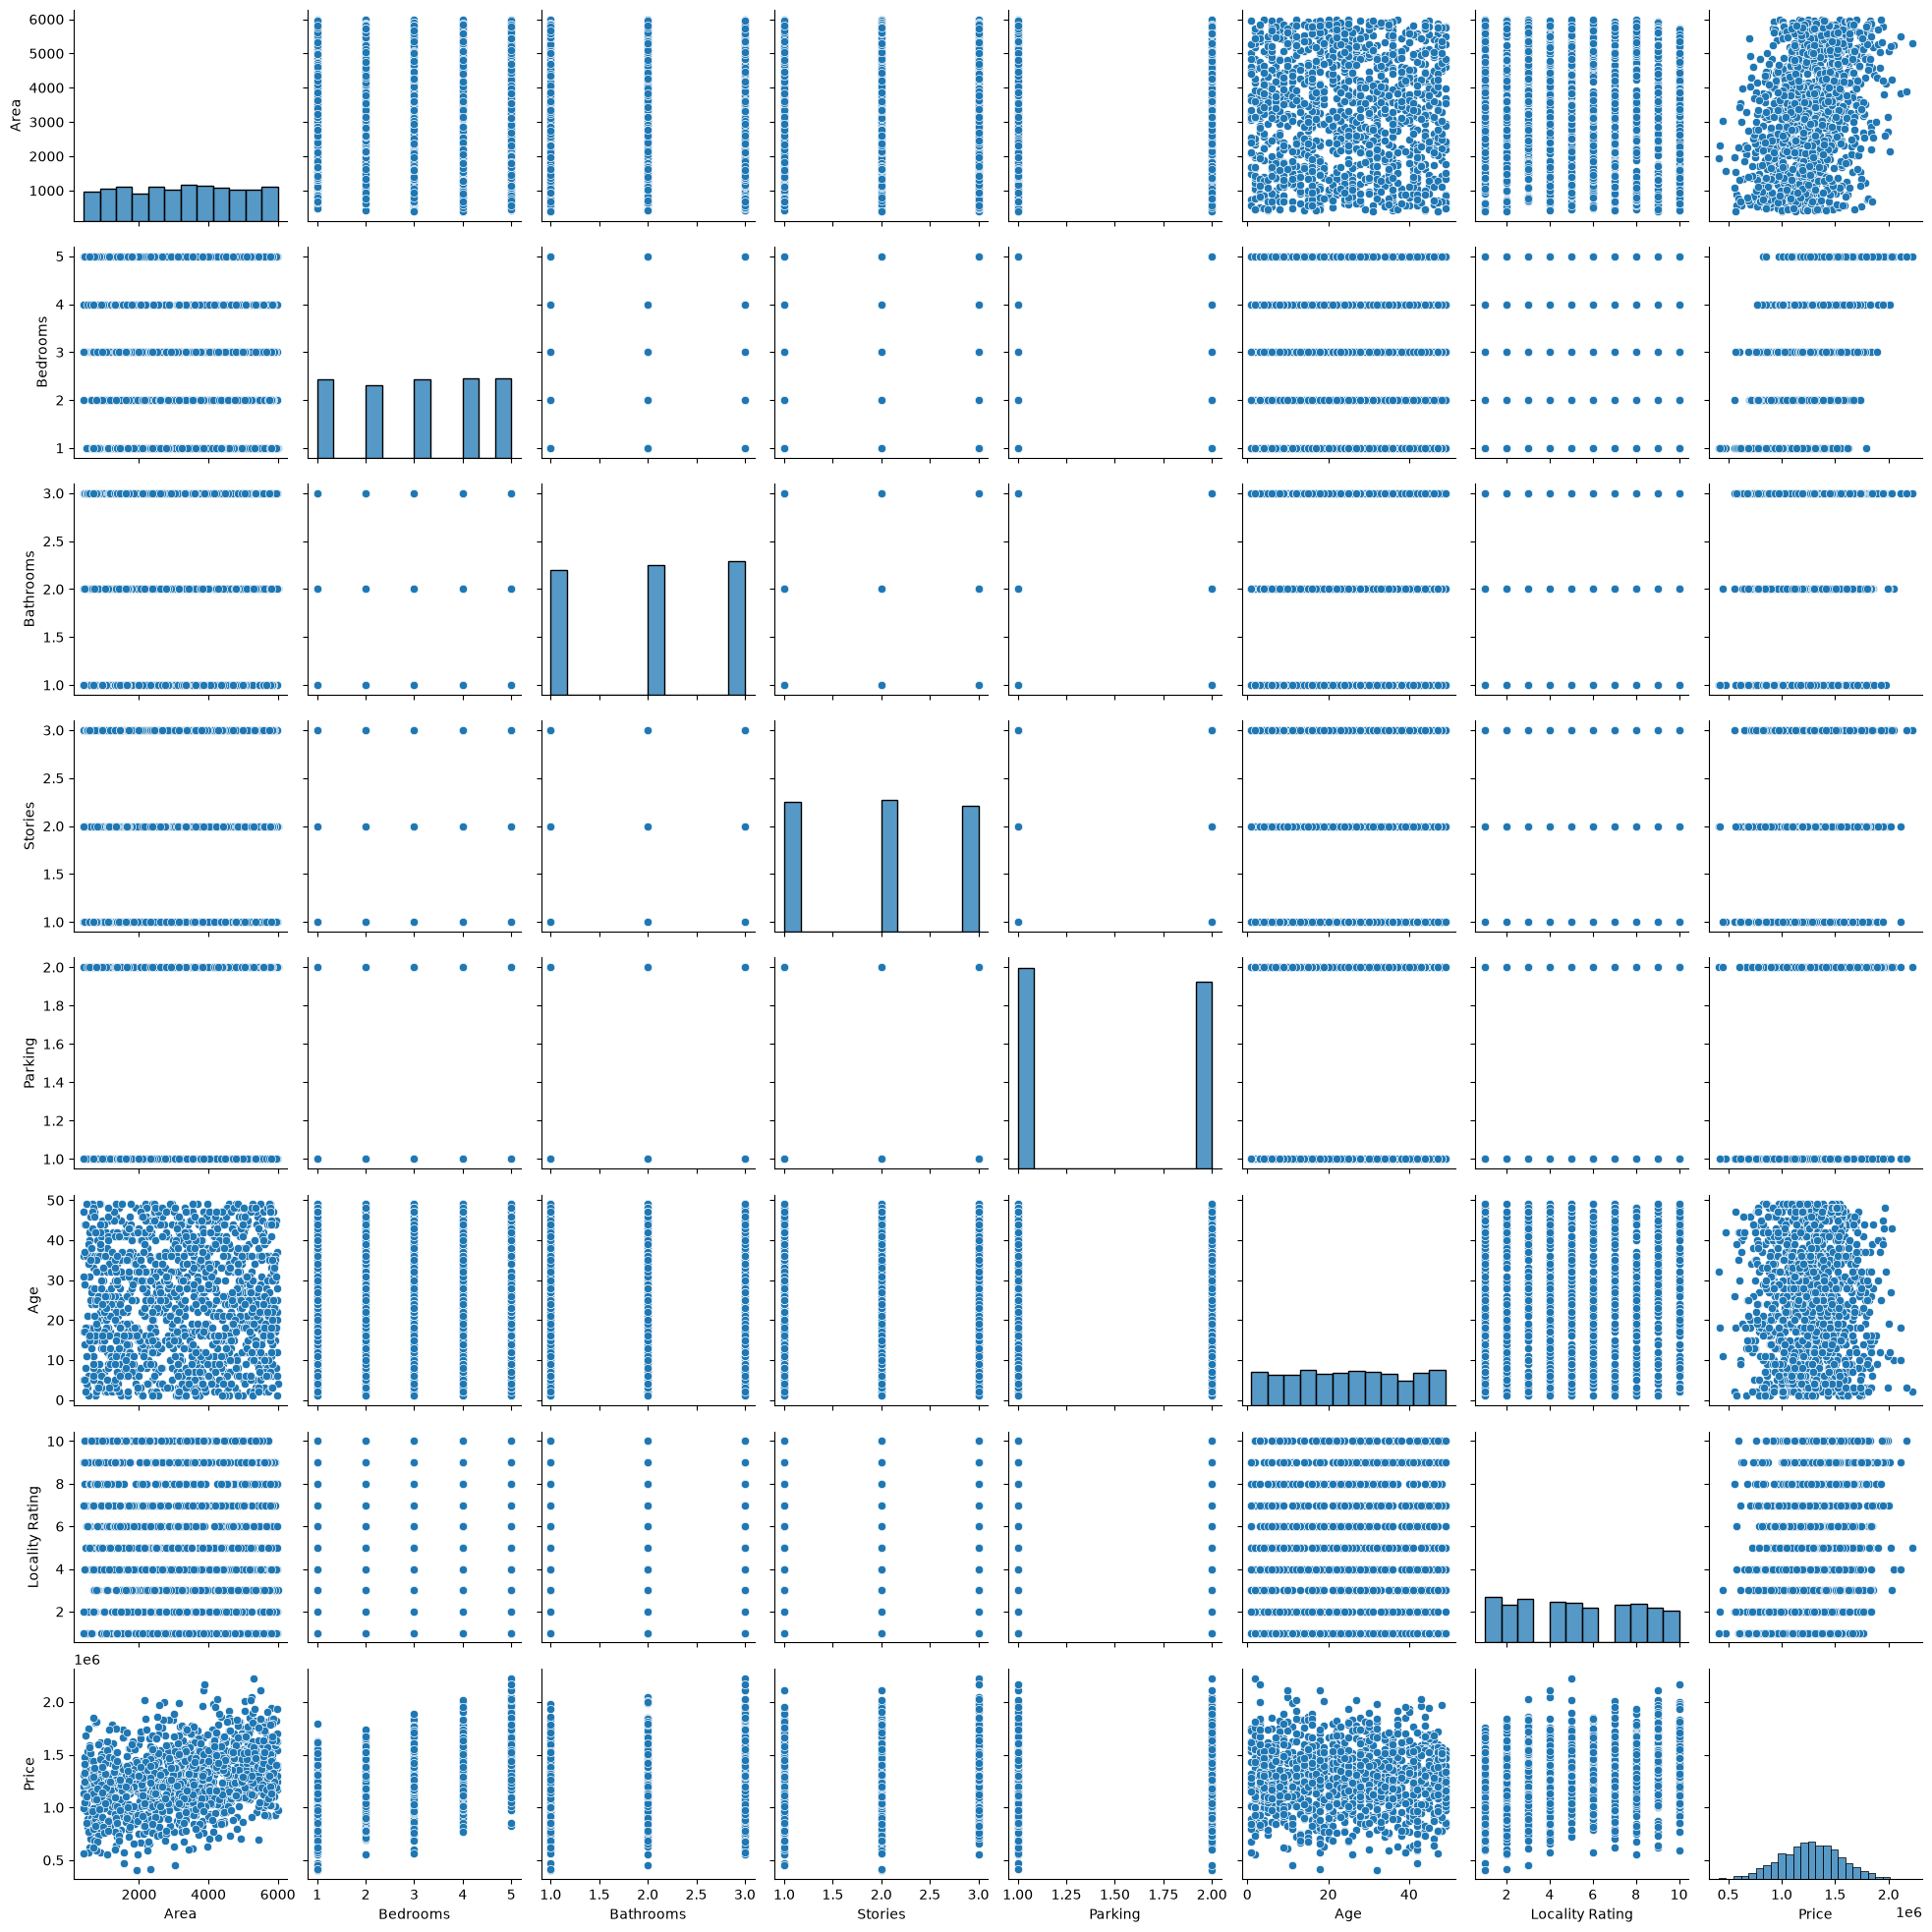

In [101]:
plt.figure(dpi=500)
sns.pairplot(df)